In [1]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# Selection

In [ ]:
dtypes = {
    "id": "string",
    # "ra": "float32",
    # "dec": "float32",
    # --- gaia ---
    "gaia_source_id": "string",
    # "parallax": "float32",
    "gaia_ruwe": "float32",
    # "gaia_parallax_over_error": "float32",
    # "gaia_classprob_dsc_combmod_star": "float32",
    # "gaia_in_qso_candidates": "int8",
    # "gaia_in_galaxy_candidates": "int8",
    # "gaia_phot_bp_rp_excess_factor": "float32",
    # "err_mag_psf_u": "float32",
    # "err_mag_psf_j0378": "float32",
    # "err_mag_psf_j0395": "float32",
    # "err_mag_psf_j0410": "float32",
    # "err_mag_psf_j0430": "float32",
    # "err_mag_psf_g": "float32",
    # "err_mag_psf_j0515": "float32",
    # "err_mag_psf_r": "float32",
    # "err_mag_psf_j0660": "float32",
    # "err_mag_psf_i": "float32",
    # "err_mag_psf_j0861": "float32",
    # "err_mag_psf_z": "float32",
    # # --- magnitudes ---
    # "mag_psf_u": "float32",
    # "mag_psf_j0378": "float32",
    # "mag_psf_j0395": "float32",
    # "mag_psf_j0410": "float32",
    # "mag_psf_j0430": "float32",
    # "mag_psf_g": "float32",
    # "mag_psf_j0515": "float32",
    # "mag_psf_r": "float32",
    # "mag_psf_j0660": "float32",
    # "mag_psf_i": "float32",
    # "mag_psf_j0861": "float32",
    # "mag_psf_z": "float32"
    # --- erros magnitudes ---
    # "err_mag_pstotal_u": "float32",
    # "err_mag_pstotal_j0378": "float32",
    # "err_mag_pstotal_j0395": "float32",
    # "err_mag_pstotal_j0410": "float32",
    # "err_mag_pstotal_j0430": "float32",
    # "err_mag_pstotal_g": "float32",
    # "err_mag_pstotal_j0515": "float32",
    # "err_mag_pstotal_r": "float32",
    # "err_mag_pstotal_j0660": "float32",
    # "err_mag_pstotal_i": "float32",
    # "err_mag_pstotal_j0861": "float32",
    # "err_mag_pstotal_z": "float32",
    # # --- magnitudes ---
    # "mag_pstotal_u": "float32",
    # "mag_pstotal_j0378": "float32",
    # "mag_pstotal_j0395": "float32",
    # "mag_pstotal_j0410": "float32",
    # "mag_pstotal_j0430": "float32",
    # "mag_pstotal_g": "float32",
    # "mag_pstotal_j0515": "float32",
    # "mag_pstotal_r": "float32",
    # "mag_pstotal_j0660": "float32",
    # "mag_pstotal_i": "float32",
    # "mag_pstotal_j0861": "float32",
    # "mag_pstotal_z": "float32"

}


full = pd.read_csv(
    "/mnt/hdcasa/splus_gaia/oficial/MC.csv",
    engine="pyarrow",
    dtype=dtypes,   
    usecols=list(dtypes.keys())
)

In [3]:
len(full)

21069162

In [2]:
full = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/all_detections_mc.csv')

/tmp/ipykernel_235223/749054019.py:1: DtypeWarning: Columns (41) have mixed types. Specify dtype option on import or set low_memory=False.
  full = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/all_detections_mc.csv')


In [4]:
import pandas as pd
from astropy.table import Table
from astroquery.gaia import Gaia

def crossmatch_gaia_dr3(df, ra_col="ra", dec_col="dec", id_col="id", radius_arcsec=2.0):
    df_up = df[[id_col, ra_col, dec_col]]
    tab = Table.from_pandas(df_up)

    query = f"""
    SELECT
        u.{id_col} AS id_splus,
        u.{ra_col} AS my_ra,
        u.{dec_col} AS my_dec,
        g.source_id,
        g.ra AS gaia_ra,
        g.dec AS gaia_dec,
        g.parallax,
        g.gaia_ruwe,
        DISTANCE(
            POINT('ICRS', u.{ra_col}, u.{dec_col}),
            POINT('ICRS', g.ra, g.dec)
        ) AS dist_deg
    FROM
        TAP_UPLOAD.my_cat AS u
    JOIN
        gaiadr3.gaia_source AS g
    ON
        1 = CONTAINS(
            POINT('ICRS', g.ra, g.dec),
            CIRCLE('ICRS', u.{ra_col}, u.{dec_col}, {radius_arcsec}/3600.0)
        )
    """

    job = Gaia.launch_job_async(
        query=query,
        upload_resource=tab,
        upload_table_name="my_cat"
    )

    res = job.get_results().to_pandas()
    res["dist_arcsec"] = res["dist_deg"] * 3600.0
    return res

Some IP addresses of users launching heavy query showers have temporarily been disabled. Please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk) for advice. Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [5]:
matches = crossmatch_gaia_dr3(full, ra_col="ra", dec_col="dec", id_col="id", radius_arcsec=2.0)
print(matches.head())

: 

: 

In [4]:
len(full)

9851615

In [5]:
full = full[(full['err_mag_psf_j0660'] < 0.2)&
        (full['err_mag_psf_i'] < 0.2)&
        (full['err_mag_psf_r'] < 0.2)&
        (full['mag_psf_j0660']/full['err_mag_psf_j0660'] > 10)&
        (full['mag_psf_i']/full['err_mag_psf_i'] > 10)&
        (full['mag_psf_r']/full['err_mag_psf_r'] > 10)]
        # (full['gaia_ruwe'] < 1.4) &
        # (full['gaia_parallax_over_error'] > 3) &
        # (full['gaia_classprob_dsc_combmod_star'] > 0.5) &
        # (full['gaia_in_qso_candidates'] == 0) &
        # (full['gaia_in_galaxy_candidates'] == 0) &
        # (full['gaia_phot_bp_rp_excess_factor'].between(1.0, 1.3))]

In [7]:
full= full[full['mag_psf_r'].between(13, 19.5)]

In [9]:
len(full)

9851615

In [11]:
df = pd.DataFrame()

In [12]:
import pandas as pd

df["mc"] = full["id"].astype(str).str.extract(r"(MC\d{4})")
counts = df["mc"].value_counts().reset_index()
counts.columns = ["mc", "count"]

print(counts)

         mc   count
0    MC0064  502217
1    MC0065  498525
2    MC0115  451902
3    MC0094  390170
4    MC0095  350772
..      ...     ...
141  MC0057    5843
142  MC0052    5768
143  MC0056    5696
144  MC0055    5653
145  MC0054    5638

[146 rows x 2 columns]


In [13]:
counts

,mc,count
0,MC0064,502217
1,MC0065,498525
2,MC0115,451902
3,MC0094,390170
4,MC0095,350772
...,...,...
141,MC0057,5843
142,MC0052,5768
143,MC0056,5696
144,MC0055,5653


In [15]:
counts.to_csv("completeness_mc_gaia.csv", index=False)

In [14]:
(full['id'].unique()).size

9127843

In [11]:
full['mag_psf_r'].describe()

count    9.024126e+06
mean     1.846271e+01
std      9.673176e-01
min      1.300002e+01
25%      1.812776e+01
50%      1.878600e+01
75%      1.909885e+01
max      1.950000e+01
Name: mag_psf_r, dtype: float64

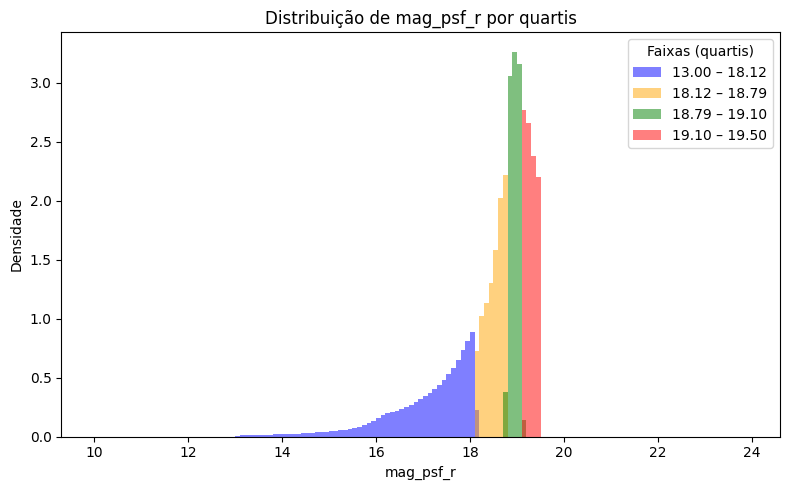

In [32]:
# Quartis
quartis = np.percentile(full['mag_psf_r'], [25, 50, 75])
colors = ['blue', 'orange', 'green', 'red']

# Limites dos quartis (incluindo min e max)
q_bounds = [full['mag_psf_r'].min()] + quartis.tolist() + [full['mag_psf_r'].max()]

plt.figure(figsize=(8,5))

for i in range(4):
    lower = q_bounds[i]
    upper = q_bounds[i+1]

    if i == 0:
        subset = full[full['mag_psf_r'] <= upper]
    elif i == 3:
        subset = full[full['mag_psf_r'] > lower]
    else:
        subset = full[(full['mag_psf_r'] > lower) & (full['mag_psf_r'] <= upper)]

    plt.hist(
        subset['mag_psf_r'],
        bins=np.arange(10, 24, 0.1),
        density=True,
        alpha=0.5,
        color=colors[i],
        label=f'{lower:.2f} – {upper:.2f}'
    )

plt.xlabel('mag_psf_r')
plt.ylabel('Densidade')
plt.title('Distribuição de mag_psf_r por quartis')
plt.legend(title='Faixas (quartis)')
plt.tight_layout()
plt.show()

In [18]:
import numpy as np

def fit_basic_and_upper_envelope(x_series, y_series,
                                 k_lower=0.5, k_upper=3.0,
                                 max_iter=4, min_pts=20):
    """
    Calcula (sem plotar) um ajuste linear básico e um ajuste 'upper-envelope'
    via σ-clipping assimétrico.

    Parameters
    ----------
    x_series, y_series : array-like
        Dados de entrada.
    k_lower, k_upper : float
        Limiares (em sigmas) para o σ-clipping assimétrico (inferior/superior).
    max_iter : int
        Número máximo de iterações do σ-clipping.
    min_pts : int
        Mínimo de pontos para manter o ajuste estável.

    Returns
    -------
    result : dict
        {
          'n_init': int,                 # pontos válidos iniciais
          'basic': {
              'ok': bool,
              'm': float or None,
              'b': float or None
          },
          'upper': {
              'ok': bool,
              'm': float or None,
              'b': float or None,
              'n_final': int or None,    # pontos após clipping
              'iters': int,              # iterações realizadas
              'mask_used': np.ndarray or None  # máscara (sobre válidos) dos pontos retidos
          },
          'x_domain': (float, float)     # (xmin, xmax) úteis
        }
    """
    # --- limpeza
    x = np.asarray(x_series, dtype=float)
    y = np.asarray(y_series, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    n_init = x.size

    xmin = float(np.min(x)) if n_init else np.nan
    xmax = float(np.max(x)) if n_init else np.nan

    result = {
        'n_init': int(n_init),
        'basic': {'ok': False, 'm': None, 'b': None},
        'upper': {'ok': False, 'm': None, 'b': None, 'n_final': None, 'iters': 0, 'mask_used': None},
        'x_domain': (xmin, xmax),
    }

    # --- ajuste básico
    if n_init >= 2 and not np.isclose(x.std(), 0.0):
        try:
            m_basic, b_basic = np.polyfit(x, y, 1)
            result['basic'] = {'ok': True, 'm': float(m_basic), 'b': float(b_basic)}
        except np.linalg.LinAlgError:
            pass  # mantém ok=False

    # --- upper-envelope (σ-clipping assimétrico)
    if n_init >= max(min_pts, 2) and not np.isclose(x.std(), 0.0):
        try:
            m, b = np.polyfit(x, y, 1)
            keep = np.ones_like(x, dtype=bool)
            prev_n = x.size
            iters = 0

            for it in range(max_iter):
                r = y - (m * x + b)
                mad = np.median(np.abs(r - np.median(r)))
                sigma = 1.4826 * mad if mad > 0 else r.std()
                if not np.isfinite(sigma) or sigma == 0:
                    break

                keep = (r > -k_lower * sigma) & (r < k_upper * sigma)
                if keep.sum() < min_pts or keep.sum() == prev_n:
                    iters = it + 1
                    break

                x, y = x[keep], y[keep]
                prev_n = x.size
                iters = it + 1
                m, b = np.polyfit(x, y, 1)

            result['upper'] = {
                'ok': True,
                'm': float(m),
                'b': float(b),
                'n_final': int(x.size),
                'iters': int(iters),
                # máscara em relação ao conjunto válido original:
                'mask_used': keep if keep.shape[0] == valid.sum() else None
            }
        except np.linalg.LinAlgError:
            pass  # mantém ok=False

    return result


# (Opcional) Função de plot que usa o resultado já calculado
def plot_scatter_with_two_fits(ax, x_series, y_series, label,
                               color_upper='orange', color_basic='black',
                               fit_result=None, scatter=True):
    """
    Plota (opcionalmente) os pontos e as retas usando um 'fit_result' já calculado.
    Se 'fit_result' for None, calcula internamente.
    """
    x = np.asarray(x_series, dtype=float)
    y = np.asarray(y_series, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]

    if fit_result is None:
        fit_result = fit_basic_and_upper_envelope(x, y)

    if scatter:
        ax.scatter(x, y, s=0.5, label=label, color='white', alpha=0.3,
                   edgecolors='black', linewidths=0.1)

    xmin, xmax = fit_result['x_domain']
    if not np.isfinite([xmin, xmax]).all() or xmin == xmax:
        if x.size:
            xmin, xmax = x.min(), x.max()
        else:
            return  # nada a plotar
    x_fit = np.linspace(xmin, xmax, 100)

    # reta básica
    if fit_result['basic']['ok']:
        m, b = fit_result['basic']['m'], fit_result['basic']['b']
        ax.plot(x_fit, m * x_fit + b, lw=1, color=color_basic,
                label=f'Fit: y = {m:.2f}x + {b:.2f}')

    # reta upper-envelope
    if fit_result['upper']['ok']:
        m, b = fit_result['upper']['m'], fit_result['upper']['b']
        ax.plot(x_fit, m * x_fit + b, lw=1, linestyle='--', color=color_upper,
                label=f'Upper-σ: y = {m:.2f}x + {b:.2f}')

In [19]:
# Máscaras
m1 = (full['mag_psf_r'] <= q_bounds[1])
m2 = (full['mag_psf_r'] > 18) & (full['mag_psf_r'] <= 19)
m3 = (full['mag_psf_r'] > 19) & (full['mag_psf_r'] <= 20)
m4 = (full['mag_psf_r'] > 20) & (full['mag_psf_r'] <= 21)

def color_x(df):  # r - i
    return df['mag_psf_r'] - df['mag_psf_i']

def color_y(df):  # r - J0660
    return df['mag_psf_r'] - df['mag_psf_j0660']

results = {
    'r<=18': fit_basic_and_upper_envelope(color_x(full.loc[m1]), color_y(full.loc[m1])),
    '18<r<=19': fit_basic_and_upper_envelope(color_x(full.loc[m2]), color_y(full.loc[m2])),
    '19<r<=20': fit_basic_and_upper_envelope(color_x(full.loc[m3]), color_y(full.loc[m3])),
    '20<r<=21': fit_basic_and_upper_envelope(color_x(full.loc[m4]), color_y(full.loc[m4])),
}

# Exemplo de acesso:
for name, res in results.items():
    if res['upper']['ok']:
        print(name, 'upper:', res['upper']['m'], res['upper']['b'], 'n=', res['upper']['n_final'])
    if res['basic']['ok']:
        print(name, 'basic:', res['basic']['m'], res['basic']['b'])

r<=18 upper: 0.358218100632316 0.018112553505648162 n= 327344
r<=18 basic: 0.3331146347481632 -0.003748831081584006
18<r<=19 upper: 0.3766896487608373 0.022084458683701607 n= 351807
18<r<=19 basic: 0.38931354480070773 -0.022958519811452246
19<r<=20 upper: 0.3834889487723685 0.027193656369122826 n= 366206
19<r<=20 basic: 0.4024434161679258 -0.028013050362513812
20<r<=21 upper: 0.3924997320089605 0.03307680334455035 n= 365322
20<r<=21 basic: 0.4126991707457307 -0.036360696358501636


/tmp/ipykernel_144379/1622334127.py:120: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/marina/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


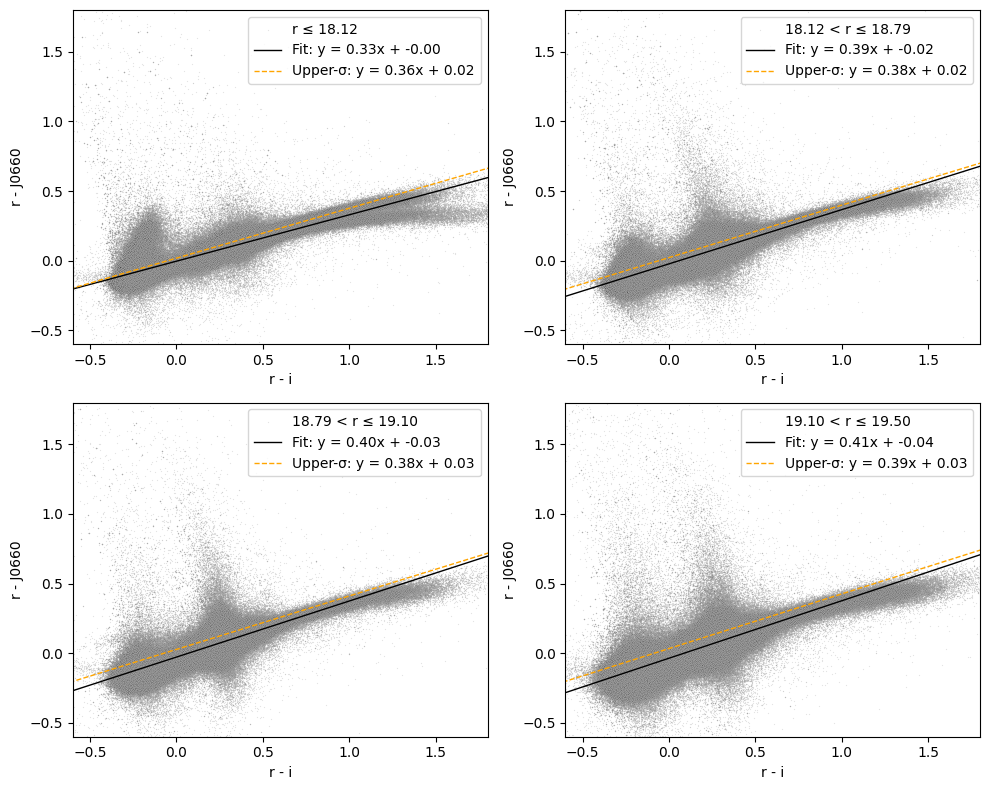

In [22]:
def plot_scatter_with_two_fits(ax, x_series, y_series, label,
                               color_upper='orange',
                               color_basic='black',
                               k_lower=0.5, k_upper=3.0,
                               max_iter=4, min_pts=20):
    """
    Plota pontos, um ajuste linear básico e um ajuste upper-envelope via σ-clipping iterativo.
    """

    # === Limpeza dos dados ===
    x = np.asarray(x_series, dtype=float)
    y = np.asarray(y_series, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    # === Scatter plot ===
    ax.scatter(
        x, y, s=0.5,
        label=label,
        color='white',
        alpha=0.3,
        edgecolors='black',
        linewidths=0.1
    )

    # === Fit básico ===
    if x.size >= 2 and not np.isclose(x.std(), 0.0):
        try:
            m_basic, b_basic = np.polyfit(x, y, 1)
            xmin, xmax = ax.get_xlim()
            if not np.isfinite([xmin, xmax]).all() or xmin == xmax:
                xmin, xmax = (x.min(), x.max())
            x_fit = np.linspace(xmin, xmax, 100)
            y_fit = m_basic * x_fit + b_basic
            ax.plot(x_fit, y_fit, lw=1, color=color_basic,
                    label=f'Fit: y = {m_basic:.2f}x + {b_basic:.2f}')
        except np.linalg.LinAlgError:
            ax.text(0.02, 0.9, "Falha no ajuste (SVD)",
                    transform=ax.transAxes, va='top', ha='left', fontsize=8)
    else:
        ax.text(0.02, 0.95, "Sem variância/pts p/ ajuste",
                transform=ax.transAxes, va='top', ha='left', fontsize=8)

    # === Upper-envelope fit ===
    if x.size >= min_pts and not np.isclose(x.std(), 0.0):
        try:
            # Ajuste inicial
            m, b = np.polyfit(x, y, 1)
            prev_n = len(x)

            for _ in range(max_iter):
                r = y - (m * x + b)
                mad = np.median(np.abs(r - np.median(r)))
                sigma = 1.4826 * mad if mad > 0 else r.std()
                if not np.isfinite(sigma) or sigma == 0:
                    break

                keep = (r > -k_lower * sigma) & (r < k_upper * sigma)
                if keep.sum() < min_pts or keep.sum() == prev_n:
                    break

                x, y = x[keep], y[keep]
                prev_n = x.size

                m, b = np.polyfit(x, y, 1)

            xmin, xmax = ax.get_xlim()
            if not np.isfinite([xmin, xmax]).all() or xmin == xmax:
                xmin, xmax = (x.min(), x.max())
            x_fit = np.linspace(xmin, xmax, 100)
            y_fit = m * x_fit + b

            ax.plot(x_fit, y_fit, color=color_upper, lw=1, linestyle='--',
                    label=f'Upper-σ: y = {m:.2f}x + {b:.2f}')

        except np.linalg.LinAlgError:
            ax.text(0.02, 0.85, "Falha upper σ-fit",
                    transform=ax.transAxes, va='top', ha='left', fontsize=8)


# Defina as máscaras dos 4 bins em r
m1 = (full['mag_psf_r'] <= q_bounds[1])
m2 = (full['mag_psf_r'] > q_bounds[1]) & (full['mag_psf_r'] <= q_bounds[2])
m3 = (full['mag_psf_r'] > q_bounds[2]) & (full['mag_psf_r'] <= q_bounds[3])
m4 = (full['mag_psf_r'] > q_bounds[3]) & (full['mag_psf_r'] <= q_bounds[4])


plt.figure(figsize=(10, 8))
ax1 = plt.subplot(221); ax2 = plt.subplot(222); ax3 = plt.subplot(223); ax4 = plt.subplot(224)

# Passe os subconjuntos diretamente (sem criar dataframes)
plot_scatter_with_two_fits(ax1,
    full.loc[m1, 'mag_psf_r'] - full.loc[m1, 'mag_psf_i'],
    full.loc[m1, 'mag_psf_r'] - full.loc[m1, 'mag_psf_j0660'],
    f'r ≤ {q_bounds[1]:.2f}'
)
plot_scatter_with_two_fits(ax2,
    full.loc[m2, 'mag_psf_r'] - full.loc[m2, 'mag_psf_i'],
    full.loc[m2, 'mag_psf_r'] - full.loc[m2, 'mag_psf_j0660'],
    f'{q_bounds[1]:.2f} < r ≤ {q_bounds[2]:.2f}'
)
plot_scatter_with_two_fits(ax3,
    full.loc[m3, 'mag_psf_r'] - full.loc[m3, 'mag_psf_i'],
    full.loc[m3, 'mag_psf_r'] - full.loc[m3, 'mag_psf_j0660'],
    f'{q_bounds[2]:.2f} < r ≤ {q_bounds[3]:.2f}'
)
plot_scatter_with_two_fits(ax4,
    full.loc[m4, 'mag_psf_r'] - full.loc[m4, 'mag_psf_i'],
    full.loc[m4, 'mag_psf_r'] - full.loc[m4, 'mag_psf_j0660'],
    f'{q_bounds[3]:.2f} < r ≤ {q_bounds[4]:.2f}'
)

for ax in (ax1, ax2, ax3, ax4):
    ax.set_xlabel('r - i')
    ax.set_ylabel('r - J0660')
    ax.set_ylim(-0.6, 1.8)
    ax.set_xlim(-0.6, 1.8)
    ax.legend()

plt.tight_layout()
plt.show()

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1) Utilidades de cores/erros e seleção Eq.(2)
# ============================================================
def color_vectors_from_df(df, column_r='mag_pstotal_r', column_i='mag_pstotal_i', column_j='mag_pstotal_j0660'):
    x = (df[column_r] - df[column_i]).to_numpy(float)       # (r - i)
    y = (df[column_r] - df[column_j]).to_numpy(float)       # (r - J0660)

    er = df[f'err_{column_r}'].to_numpy(float)
    ei = df[f'err_{column_i}'].to_numpy(float)
    ej = df[f'err_{column_j}'].to_numpy(float)

    sig_x = np.sqrt(er**2 + ei**2)   # σ_(r-i)
    sig_y = np.sqrt(er**2 + ej**2)   # σ_(r-J0660)
    return x, y, sig_x, sig_y


def select_halpha_emitters(x, y, sig_x, sig_y, m_fit, b_fit, rms, C=5.0):
    """
    Retorna:
      delta      = y - y_fit
      expr_sqrt  = sqrt(rms^2 + sig_y^2 + m^2*sig_x^2)   (termo dentro da raiz)
      thr        = C * expr_sqrt                         (Eq. 2 completa)
      emitters   = delta > thr
    """
    y_fit = m_fit * x + b_fit
    delta = y - y_fit

    rms_term = (float(rms) if rms is not None else 0.0)
    expr_sqrt = np.sqrt(rms_term**2 + sig_y**2 + (m_fit**2) * sig_x**2)
    thr = C * expr_sqrt
    emitters = delta > thr
    return delta, expr_sqrt, thr, emitters


def _extract_fit_params(fit_result=None, m=None, b=None, rms=None):
    if fit_result is not None:
        if 'upper' in fit_result and fit_result['upper'].get('ok', False):
            m = fit_result['upper']['m']; b = fit_result['upper']['b']
        elif 'basic' in fit_result and fit_result['basic'].get('ok', False):
            m = fit_result['basic']['m']; b = fit_result['basic']['b']
        if 'rms' in fit_result:
            rms = fit_result.get('rms', rms)
    return m, b, rms


# def _build_marks_df(index):
#     out = pd.DataFrame(index=index)
#     out["id"] = np.nan
#     out["ri"] = np.nan
#     out["rJ0660"] = np.nan
#     out["sig_ri"] = np.nan
#     out["sig_rJ0660"] = np.nan
#     out["delta_Ha"] = np.nan
#     out["expr_sqrt"] = np.nan
#     out["thr"] = np.nan
#     out["C_used"] = np.nan
#     out["is_Ha_emitter"] = False
#     out["panel_label"] = None
#     return out


def apply_eq12_mark_only(df, column_r, column_i, column_j,
                         fit_result=None, m=None, b=None, rms=None, C=5.0,
                         panel_label=None):
    """
    Marca emissores pela Eq.(2) e retorna APENAS as marcações (mesmo index do df).
    Preenche tudo para emissores E não emissores.
    """
    m, b, rms = _extract_fit_params(fit_result=fit_result, m=m, b=b, rms=rms)

    marks = df
    if panel_label is not None:
        marks["panel_label"] = panel_label

    # Sem parâmetros -> devolve NaN/False, mas com C e label
    if m is None or b is None:
        marks["C_used"] = float(C)
        return marks

    x, y, sig_x, sig_y = color_vectors_from_df(df, column_r=column_r, column_i=column_i, column_j=column_j)
    delta, expr_sqrt, thr, emitters = select_halpha_emitters(x, y, sig_x, sig_y, m, b, rms, C=C)

    # preenche TUDO
    marks["ri"] = x
    marks["rJ0660"] = y
    marks["sig_ri"] = sig_x
    marks["sig_rJ0660"] = sig_y
    marks["delta_Ha"] = delta
    marks["expr_sqrt"] = expr_sqrt
    marks["thr"] = thr
    marks["C_used"] = float(C)
    marks["is_Ha_emitter"] = emitters

    return marks


# ============================================================
# 2) SUA função: scatter + dois fits, agora RETORNANDO fit_result
# ============================================================
def plot_scatter_with_two_fits(ax, x_series, y_series, label,
                               color_upper='black',
                               color_basic='orange',
                               k_lower=0.5, k_upper=3.0,
                               max_iter=4, min_pts=20):
    """
    Plota pontos, um ajuste linear básico e um ajuste upper-envelope via σ-clipping iterativo.
    Agora retorna fit_result com m,b,rms (e infos auxiliares).
    """

    # === Limpeza dos dados ===
    x = np.asarray(x_series, dtype=float)
    y = np.asarray(y_series, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    fit_result = {
        "basic": {"ok": False},
        "upper": {"ok": False},
        "rms": None,
        "params": {"k_lower": k_lower, "k_upper": k_upper, "max_iter": max_iter, "min_pts": min_pts},
        "label": label,
        "n_input": int(x.size),
    }

    # === Scatter plot ===
    ax.scatter(
        x, y, s=0.5,
        label=label,
        color='white',
        alpha=0.3,
        edgecolors='black',
        linewidths=0.1
    )

    # === Fit básico ===
    m_basic = b_basic = None
    if x.size >= 2 and not np.isclose(x.std(), 0.0):
        try:
            m_basic, b_basic = np.polyfit(x, y, 1)
            fit_result["basic"] = {"ok": True, "m": float(m_basic), "b": float(b_basic), "n": int(x.size)}

            xmin, xmax = ax.get_xlim()
            if not np.isfinite([xmin, xmax]).all() or xmin == xmax:
                xmin, xmax = (x.min(), x.max())
            x_fit = np.linspace(xmin, xmax, 100)
            y_fit = m_basic * x_fit + b_basic
            ax.plot(x_fit, y_fit, lw=1, color=color_basic,linestyle='--',
                    label=f'Fit: y = {m_basic:.2f}x + {b_basic:.2f}')
        except np.linalg.LinAlgError:
            ax.text(0.02, 0.9, "Falha no ajuste (SVD)",
                    transform=ax.transAxes, va='top', ha='left', fontsize=8)
    else:
        ax.text(0.02, 0.95, "Sem variância/pts p/ ajuste",
                transform=ax.transAxes, va='top', ha='left', fontsize=8)

    # === Upper-envelope fit ===
    if x.size >= min_pts and not np.isclose(x.std(), 0.0):
        try:
            # Trabalhar em cópias para não destruir x,y originais
            xw = x.copy()
            yw = y.copy()

            # Ajuste inicial
            m, b = np.polyfit(xw, yw, 1)
            prev_n = len(xw)

            sigma_last = None
            keep_last = np.ones_like(xw, dtype=bool)

            for _ in range(max_iter):
                r = yw - (m * xw + b)
                mad = np.median(np.abs(r - np.median(r)))
                sigma = 1.4826 * mad if mad > 0 else r.std()
                if not np.isfinite(sigma) or sigma == 0:
                    break

                keep = (r > -k_lower * sigma) & (r < k_upper * sigma)
                if keep.sum() < min_pts or keep.sum() == prev_n:
                    sigma_last = float(sigma)
                    keep_last = keep
                    break

                xw, yw = xw[keep], yw[keep]
                prev_n = xw.size
                sigma_last = float(sigma)
                keep_last = keep

                m, b = np.polyfit(xw, yw, 1)

            # RMS dos resíduos no conjunto "clean" final (xw,yw)
            r_clean = yw - (m * xw + b)
            rms_clean = float(np.sqrt(np.mean(r_clean**2))) if r_clean.size > 0 else None

            fit_result["upper"] = {
                "ok": True,
                "m": float(m),
                "b": float(b),
                "sigma": sigma_last,
                "n": int(xw.size),
            }
            fit_result["rms"] = rms_clean

            xmin, xmax = ax.get_xlim()
            if not np.isfinite([xmin, xmax]).all() or xmin == xmax:
                xmin, xmax = (x.min(), x.max())
            x_fit = np.linspace(xmin, xmax, 100)
            y_fit = m * x_fit + b

            ax.plot(x_fit, y_fit, color=color_upper, lw=1, 
                    label=f'Upper-σ: y = {m:.2f}x + {b:.2f}')

        except np.linalg.LinAlgError:
            ax.text(0.02, 0.85, "Falha upper σ-fit",
                    transform=ax.transAxes, va='top', ha='left', fontsize=8)

    return fit_result


# ============================================================
# 3) EXEMPLO: seus 4 bins -> fit_result por painel + marcações Eq.(2)
# ============================================================

# Defina as máscaras dos 4 bins em r
# (mantendo exatamente seu padrão)
# m1 = (full['mag_psf_r'] <= q_bounds[1])
# m2 = (full['mag_psf_r'] > q_bounds[1]) & (full['mag_psf_r'] <= q_bounds[2])
# m3 = (full['mag_psf_r'] > q_bounds[2]) & (full['mag_psf_r'] <= q_bounds[3])
# m4 = (full['mag_psf_r'] > q_bounds[3]) & (full['mag_psf_r'] <= q_bounds[4])

def run_four_panels_and_marks(full, q_bounds, C=5.0,
                             mag_r="mag_psf_r", mag_i="mag_psf_i", mag_j="mag_psf_j0660",
                             err_prefix="err_", do_plot=True,
                             show_emitters_C=(3.0, 5.0, 8.0)):
    """
    Igual ao seu, mas agora (opcionalmente) sobrepõe os emissores para C=3,5,8
    colorindo apenas os pontos que passam o corte em cada C.
    """

    m1 = (full[mag_r] <= q_bounds[1])
    m2 = (full[mag_r] > q_bounds[1]) & (full[mag_r] <= q_bounds[2])
    m3 = (full[mag_r] > q_bounds[2]) & (full[mag_r] <= q_bounds[3])
    m4 = (full[mag_r] > q_bounds[3]) & (full[mag_r] <= q_bounds[4])
    masks = [m1, m2, m3, m4]

    labels = [
        f"r ≤ {q_bounds[1]:.2f}",
        f"{q_bounds[1]:.2f} < r ≤ {q_bounds[2]:.2f}",
        f"{q_bounds[2]:.2f} < r ≤ {q_bounds[3]:.2f}",
        f"{q_bounds[3]:.2f} < r ≤ {q_bounds[4]:.2f}",
    ]

    if do_plot:
        plt.figure(figsize=(10, 8))
        ax1 = plt.subplot(221); ax2 = plt.subplot(222); ax3 = plt.subplot(223); ax4 = plt.subplot(224)
        axes = [ax1, ax2, ax3, ax4]
    else:
        axes = [None, None, None, None]

    marks_all = full
    fit_results = []

    # cores fixas só pra distinguir os overlays (pode trocar)
    C_colors = {3.0: "#F4A7A3", 5.0: "#88CCEE", 8.0: "#79B491"}

    for ax, mask, lab in zip(axes, masks, labels):
        xbin = full.loc[mask, mag_r] - full.loc[mask, mag_i]
        ybin = full.loc[mask, mag_r] - full.loc[mask, mag_j]

        if do_plot:
            fit_res = plot_scatter_with_two_fits(ax, xbin, ybin, lab)
        else:
            fig_tmp, ax_tmp = plt.subplots(figsize=(1, 1))
            fit_res = plot_scatter_with_two_fits(ax_tmp, xbin, ybin, lab)
            plt.close(fig_tmp)

        fit_results.append(fit_res)

        # ---- (A) Marcações do seu C "principal" (mantém igual) ----
        marks_bin = apply_eq12_mark_only(
            full.loc[mask],
            column_r=mag_r, column_i=mag_i, column_j=mag_j,
            fit_result=fit_res,
            C=C,
            panel_label=lab
        )
        marks_all.loc[mask, marks_bin.columns] = marks_bin

        # ---- (B) NOVO: overlay dos emissores para C=3,5,8 ----
        if do_plot and ax is not None and show_emitters_C:
            mfit, bfit, rmsfit = _extract_fit_params(fit_result=fit_res, m=None, b=None, rms=None)

            # só faz overlay se tem fit válido
            if mfit is not None and bfit is not None:
                df_bin = full.loc[mask]
                x, y, sig_x, sig_y = color_vectors_from_df(
                    df_bin, column_r=mag_r, column_i=mag_i, column_j=mag_j
                )

                for Cc in show_emitters_C:
                    _, _, _, emit = select_halpha_emitters(x, y, sig_x, sig_y, mfit, bfit, rmsfit, C=float(Cc))
                    if np.any(emit):
                        ax.scatter(
                            x[emit], y[emit],
                            s=2,
                            alpha=0.3,
                            color=C_colors.get(float(Cc), None),
                            edgecolors="none",
                            label=f"emitters (C={Cc:g})"
                        )

        if do_plot and ax is not None:
            ax.set_xlabel('r - i')
            ax.set_ylabel('r - J0660')
            ax.set_ylim(-0.6, 1.8)
            ax.set_xlim(-0.6, 1.8)
            ax.legend()

    if do_plot:
        plt.tight_layout()
        plt.show()

    return fit_results, marks_all

/tmp/ipykernel_467377/104600885.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  marks["panel_label"] = panel_label
/tmp/ipykernel_467377/104600885.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  marks["ri"] = x
/tmp/ipykernel_467377/104600885.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.

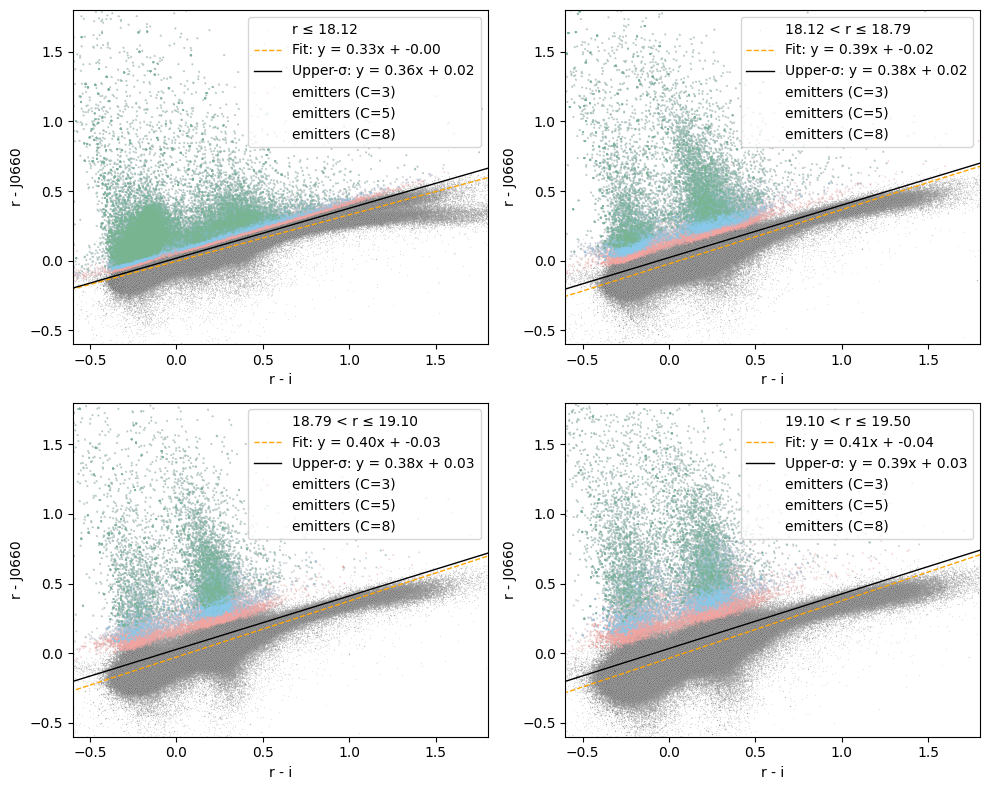

In [38]:
fit_results, marks = run_four_panels_and_marks(
    full=marks,
    q_bounds=q_bounds,
    mag_r="mag_psf_r",
    mag_i="mag_psf_i",
    mag_j="mag_psf_j0660",
    do_plot=True
)

# marks é SOMENTE as marcações, para o full inteiro (por bin)
# Ex:
# marks["is_Ha_emitter"].sum()
# marks[marks["is_Ha_emitter"]]

In [9]:
marks

,Unnamed: 0,id,ra,dec,mag_psf_g,mag_psf_i,mag_psf_j0378,mag_psf_j0395,mag_psf_j0410,mag_psf_j0430,...,panel_label,ri,rJ0660,sig_ri,sig_rJ0660,delta_Ha,expr_sqrt,thr,C_used,is_Ha_emitter
0,0,i06MC0020004AT,95.899031,-65.255725,13.377560,13.021664,14.006183,13.861927,13.531144,13.518270,...,r ≤ 18.12,0.027251,0.013816,0.000044,0.000046,-0.014059,0.008048,0.040239,5.0,False
1,1,i06MC002000SL2,96.610553,-65.141041,13.986011,12.897835,15.872704,15.406844,14.753924,14.569132,...,r ≤ 18.12,0.299628,0.117157,0.000040,0.000045,-0.008287,0.008048,0.040239,5.0,False
2,2,i06MC000202A3F,70.297352,-62.851360,12.407158,12.970738,12.780666,12.618521,11.960797,11.912725,...,r ≤ 18.12,0.048881,0.257562,0.000083,0.000075,0.221939,0.008048,0.040241,5.0,True
3,3,i06MC000805R76,87.496871,-63.060088,13.431721,12.925622,14.065097,13.931953,13.536164,13.464466,...,r ≤ 18.12,0.122595,0.044084,0.000475,0.000663,-0.017944,0.008077,0.040384,5.0,False
4,4,i06MC000406508,76.541405,-62.788187,12.997478,13.388355,13.778458,13.670442,13.797226,13.875636,...,r ≤ 18.12,-0.191541,-1.975719,0.000107,0.000717,-1.925218,0.008080,0.040399,5.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9851610,9851610,i06MC00630HH8J,74.538507,-68.995977,20.020370,18.978193,NaN,NaN,NaN,NaN,...,18.12 < r ≤ 18.79,-0.759129,0.839816,0.220720,0.227523,1.103687,0.242503,1.212515,5.0,False
9851611,9851611,i06MC00150B3Y8,81.296374,-63.831396,19.649454,18.355351,NaN,NaN,NaN,NaN,...,18.12 < r ≤ 18.79,0.251221,-0.080468,0.198368,0.198142,-0.197185,0.212067,1.060335,5.0,False
9851612,9851612,i06MC00870FEBJ,77.178672,-70.310665,NaN,18.819698,NaN,NaN,NaN,NaN,...,18.12 < r ≤ 18.79,-0.143477,-0.177562,0.204517,0.235918,-0.145600,0.248436,1.242182,5.0,False
9851613,9851613,i06MC00620000P,69.492552,-70.411438,20.848533,17.626540,NaN,NaN,NaN,NaN,...,r ≤ 18.12,0.131513,-2.559566,0.215744,0.239017,-2.624788,0.251330,1.256650,5.0,False


In [ ]:
plt.scatter(marks)

In [14]:
marks.to_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/all_detections_mc.csv', index=False)

In [2]:
marks = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/all_detections_mc.csv')

/tmp/ipykernel_5779/1485448797.py:1: DtypeWarning: Columns (41) have mixed types. Specify dtype option on import or set low_memory=False.
  marks = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/all_detections_mc.csv')


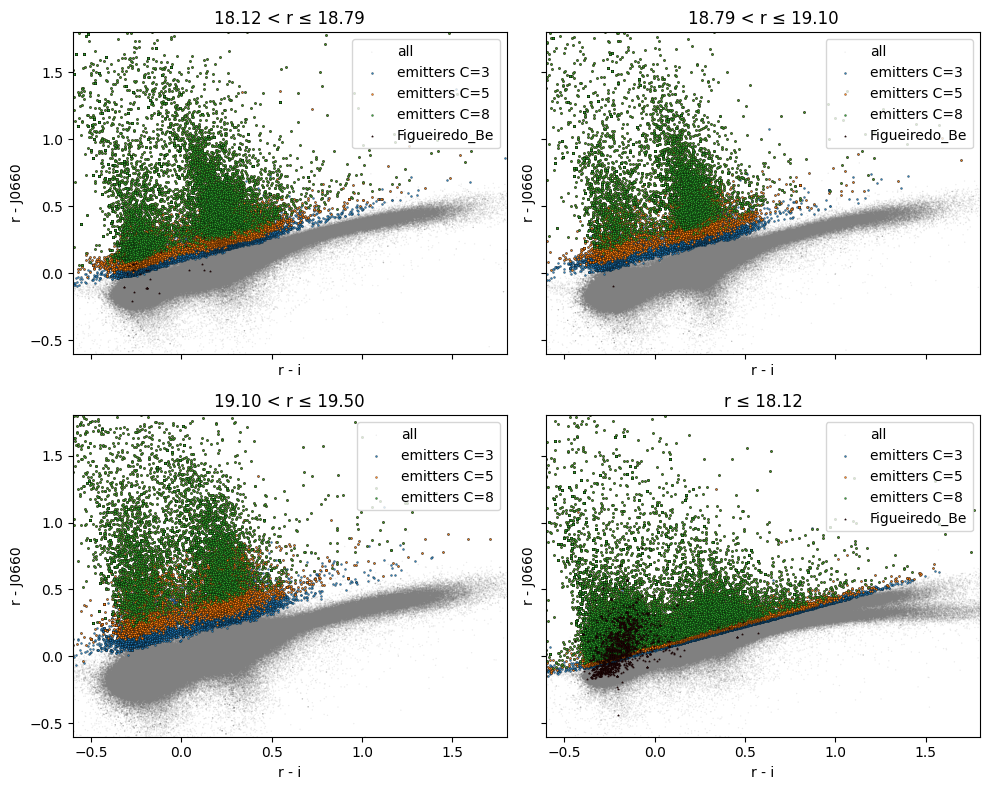

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_marks_base(
    marks_all,
    C_list=(3.0, 5.0, 8.0),
    figueiredo_col="Figueiredo_Be",
    panel_col="panel_label",
    show_panels=False,          # se True, faz 4 subplots por panel_label
):
    df = marks_all.copy()

    # garante colunas essenciais
    need = ["ri", "rJ0660", "delta_Ha", "expr_sqrt"]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise ValueError(f"Faltam colunas na tabela de saída: {missing}")

    # cria flags por C usando SOMENTE a tabela de saída
    for C in C_list:
        df[f"is_Ha_C{int(C)}"] = df["delta_Ha"] > (float(C) * df["expr_sqrt"])

    # Figueiredo flag
    if figueiredo_col not in df.columns:
        df[figueiredo_col] = False  # se não existir, não quebra
    fig_mask = df[figueiredo_col].fillna(False).astype(bool).to_numpy()

    # helper: desenha um painel
    def _draw(ax, dfx, title=""):
        x = dfx["ri"].to_numpy(float)
        y = dfx["rJ0660"].to_numpy(float)
        base = np.isfinite(x) & np.isfinite(y)

        # base (todos)
        ax.scatter(
            x[base], y[base],
            s=1, alpha=0.15,
            color="gray", edgecolors="none",
            label="all"
        )

        # emissores por C (overlay)
        # (ordem: maior C por cima normalmente fica melhor)
        for C in sorted(C_list):
            col = f"is_Ha_C{int(C)}"
            m = base & dfx[col].to_numpy(bool)
            if np.any(m):
                ax.scatter(
                    x[m], y[m],
                    s=2, alpha=0.9,
                    edgecolors="black", linewidths=0.2,
                    label=f"emitters C={int(C)}"
                )

        # destaque Figueiredo_Be
        mfig = base & dfx[figueiredo_col].fillna(False).astype(bool).to_numpy()
        if np.any(mfig):
            ax.scatter(
                x[mfig], y[mfig],
                s=2, marker="*", alpha=1.0,
                edgecolors="black", linewidths=0.3,
                label="Figueiredo_Be"
            )

        ax.set_xlabel("r - i")
        ax.set_ylabel("r - J0660")
        ax.set_xlim(-0.6, 1.8)
        ax.set_ylim(-0.6, 1.8)
        ax.set_title(title)
        ax.legend(loc="best")

    # ---- plot simples (1 painel) ou por panel_label (4 painéis) ----
    if show_panels and panel_col in df.columns:
        panels = [p for p in df[panel_col].dropna().unique()]
        panels = sorted(panels)[:4]  # garante 4 no máximo

        fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
        axes = axes.ravel()

        for i, p in enumerate(panels):
            dfx = df[df[panel_col] == p]
            _draw(axes[i], dfx, title=str(p))

        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(7, 6))
        ax = plt.gca()
        _draw(ax, df, title="Hα selection (from marks table)")
        plt.tight_layout()
        plt.show()

plot_marks_base(marks, C_list=(3,5,8), figueiredo_col="Figueiredo_Be", show_panels=True)

In [9]:
marks['h_alpha_emitters_3sigma'] = marks['delta_Ha'] > (3.0 * marks['expr_sqrt'])
marks['h_alpha_emitters_5sigma'] = marks['delta_Ha'] > (5.0 * marks['expr_sqrt'])


In [11]:
marks.drop(columns=['Unnamed: 0','C_used', 'is_Ha_emitter'], inplace=True)

In [12]:
marks.columns

Index(['id', 'ra', 'dec', 'mag_psf_g', 'mag_psf_i', 'mag_psf_j0378',
       'mag_psf_j0395', 'mag_psf_j0410', 'mag_psf_j0430', 'mag_psf_j0515',
       'mag_psf_j0660', 'mag_psf_j0861', 'mag_psf_r', 'mag_psf_u', 'mag_psf_z',
       'err_mag_psf_g', 'err_mag_psf_i', 'err_mag_psf_j0378',
       'err_mag_psf_j0395', 'err_mag_psf_j0410', 'err_mag_psf_j0430',
       'err_mag_psf_j0515', 'err_mag_psf_j0660', 'err_mag_psf_j0861',
       'err_mag_psf_r', 'err_mag_psf_u', 'err_mag_psf_z',
       'h_alpha_emitters_8sigma', 's2noise_r', 'unique_values_kept',
       'outside_cluster', 'cluster_index', 'star_index', 'sep_arcsec',
       'sep_arcmin', 'cluster_ra', 'cluster_dec', 'cluster_amaj',
       'cluster_Names', 'cluster_Type', 'cluster_[M/H]', 'cluster_r_[M/H]',
       'star_ra', 'star_dec', 'star_id', 'Figueiredo_Be', 'Names', 'logAge',
       'be_candidates_by_color', 'name', 'Age', 'Age2', 'AgeBicaGlatt',
       'panel_label', 'ri', 'rJ0660', 'sig_ri', 'sig_rJ0660', 'delta_Ha',
       'exp

In [16]:
print(marks['h_alpha_emitters_3sigma'].sum(), marks['h_alpha_emitters_5sigma'].sum(), marks['h_alpha_emitters_8sigma'].sum())

138305 86303 55302


In [26]:
# Contagens (Be do Figueiredo dentro dos emissores) + totais de emissores + frações
for s in [3, 5, 8]:
    emit_col = f"h_alpha_emitters_{s}sigma"

    n_emit = int(marks[emit_col].sum())
    n_be_in_emit = int((marks[emit_col] & marks["Figueiredo_Be"]).sum())

    frac = (n_be_in_emit / n_emit) if n_emit > 0 else np.nan

    print(
        f"[{s}σ] Total emitters = {n_emit:,} | "
        f"Figueiredo_Be e emitters = {n_be_in_emit:,} | "
        f"fração (Be entre emitters) = {frac:.4f}"
    )

[3σ] Total emitters = 138,305 | Figueiredo_Be e emitters = 995 | fração (Be entre emitters) = 0.0072
[5σ] Total emitters = 86,303 | Figueiredo_Be e emitters = 930 | fração (Be entre emitters) = 0.0108
[8σ] Total emitters = 55,302 | Figueiredo_Be e emitters = 804 | fração (Be entre emitters) = 0.0145


In [16]:
from astroquery.xmatch import XMatch
import io
import astropy.units as u

table = XMatch.query(
    cat1=open('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/all_detections_mc.csv'),
    cat2='simbad',
    max_distance=2* u.arcsec,
    colRA1='ra',
    colDec1='dec'
)

ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

In [44]:
tb = table.to_pandas()

In [47]:
len(table)

6818

In [45]:
tb.to_csv('/home/shared/splus_gaia/data/halpha_emitters-gustabin/MC_simbad.csv', index=False)

In [17]:
tb.columns

Index(['angDist', 'id', 'ra', 'dec', 'parallax', 'err_mag_pstotal_r',
       'err_mag_pstotal_i', 'err_mag_pstotal_j0660', 'gaia_ruwe',
       'gaia_parallax_over_error', 'gaia_classprob_dsc_combmod_star',
       'gaia_in_qso_candidates', 'gaia_in_galaxy_candidates',
       'gaia_phot_bp_rp_excess_factor', 'mag_pstotal_r', 'mag_pstotal_i',
       'mag_pstotal_j0660', 'main_id', 'ra2', 'dec2', 'coo_err_maj',
       'coo_err_min', 'coo_err_angle', 'otype', 'nbref', 'ra_sexa', 'dec_sexa',
       'coo_qual', 'coo_bibcode', 'main_type', 'other_types', 'radvel',
       'radvel_err', 'redshift', 'redshift_err', 'sp_type', 'morph_type',
       'plx', 'plx_err', 'pmra', 'pmdec', 'pm_err_maj', 'pm_err_min',
       'pm_err_pa', 'size_maj', 'size_min', 'size_angle', 'B', 'V', 'R', 'J',
       'H', 'K', 'u', 'g', 'r', 'i', 'z'],
      dtype='object')

In [46]:
tb.groupby('main_type').size().reset_index(name='counts').sort_values(by='counts', ascending=False)

,main_type,counts
66,Star,1464
24,EmLine*,1276
56,RRLyrae,934
22,EclBin,632
48,PlanetaryNeb,305
...,...,...
35,HighVel*,1
69,Supergiant_Candidate,1
17,ClG,1
40,Maser,1


In [21]:
galaxies = tb[tb['otype'] == 'G']

In [20]:
galaxies.to_csv('../data/halpha_emitters_galaxies.csv', index=False)

In [21]:
binaries = tb[tb['main_type'].isin(['EclBin', 'EclBin_Candidate'])]

In [22]:
binaries.to_csv('../data/halpha_emitters_binaries.csv', index=False)

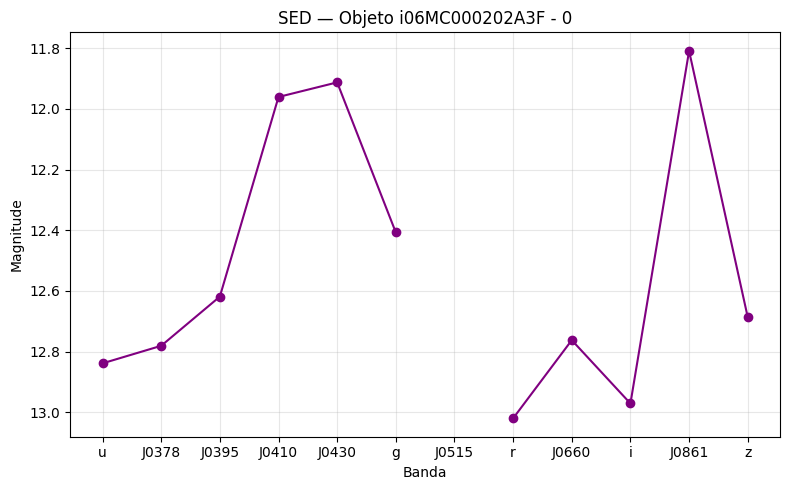

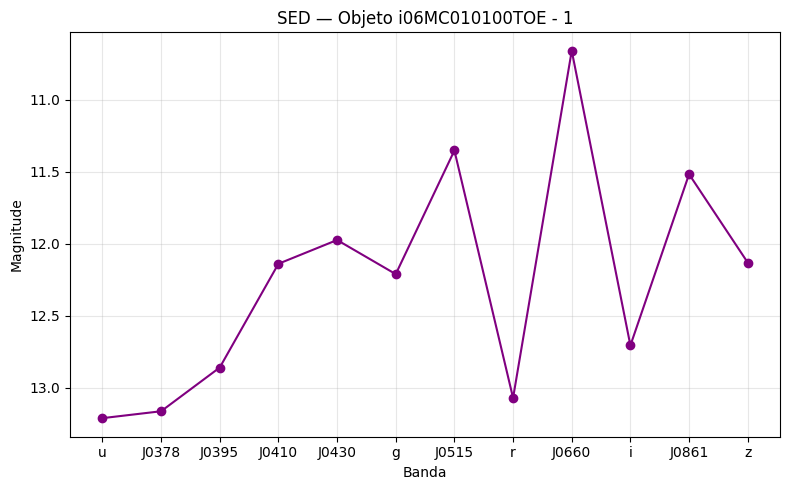

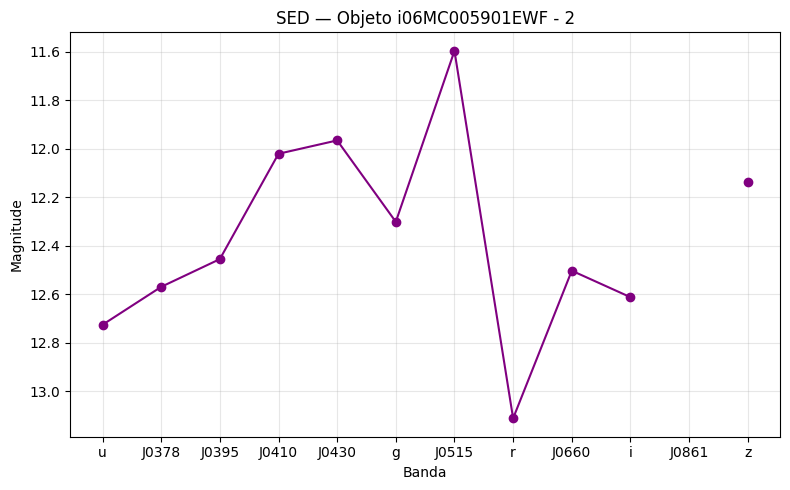

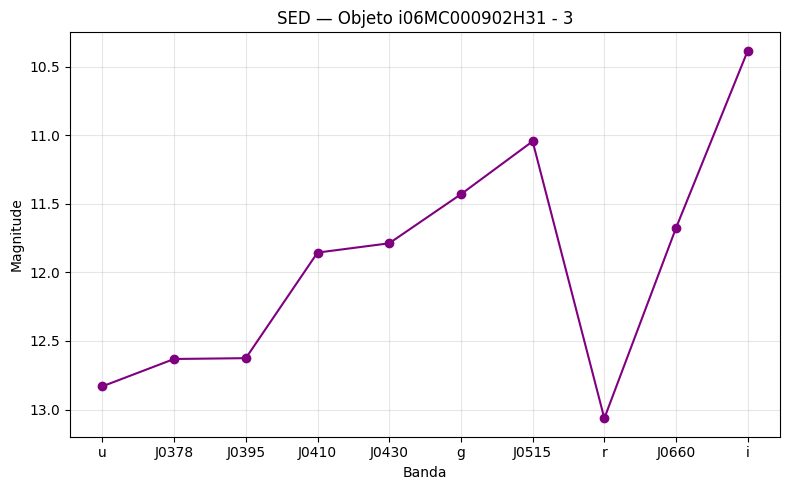

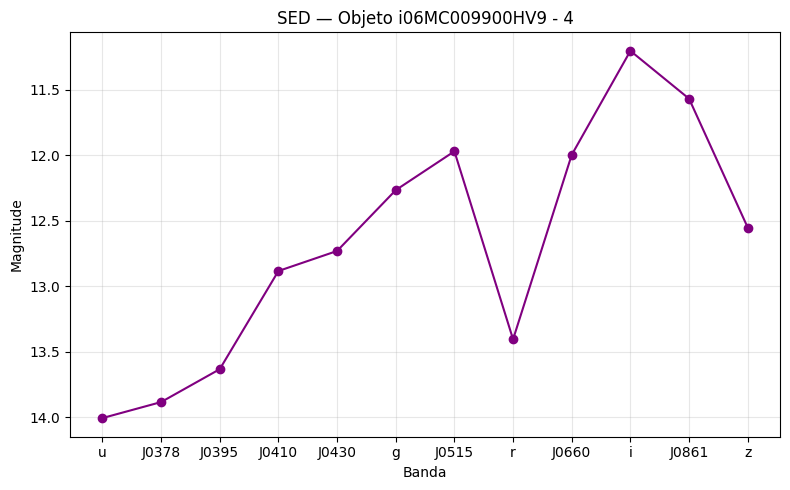

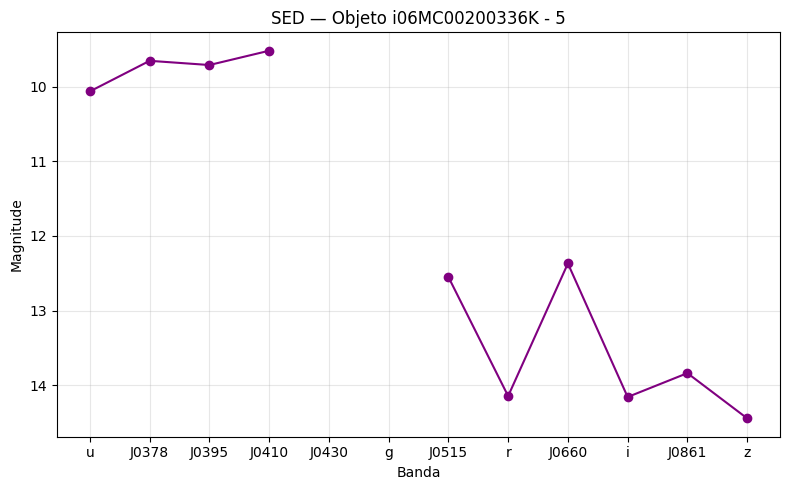

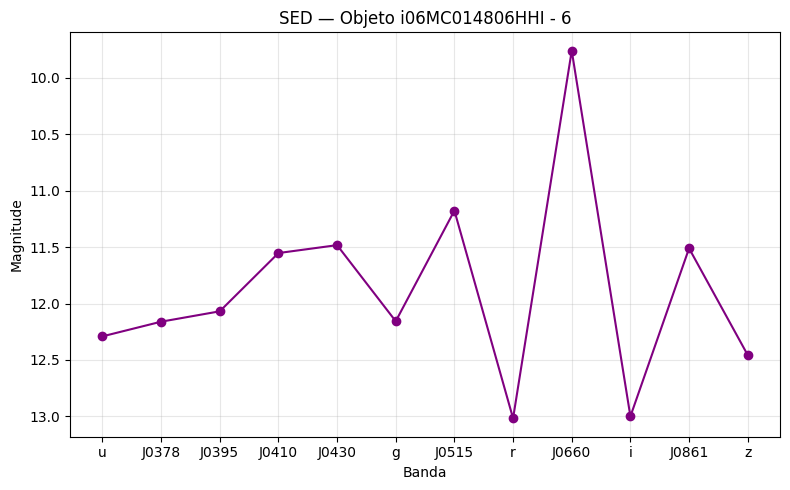

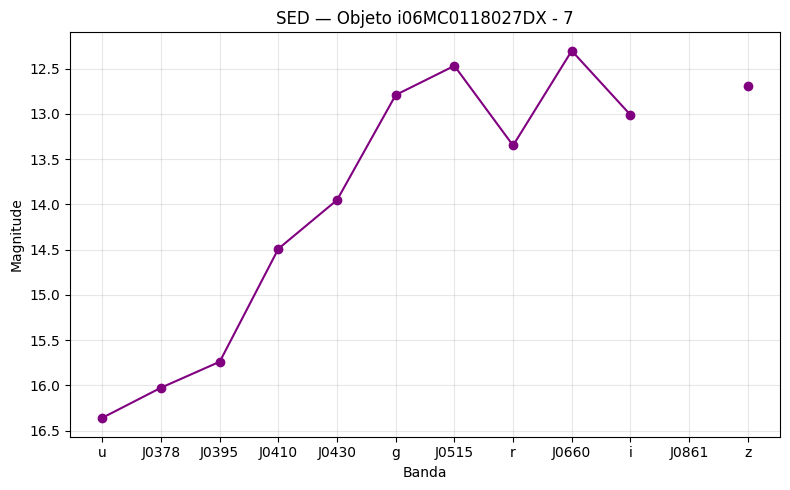

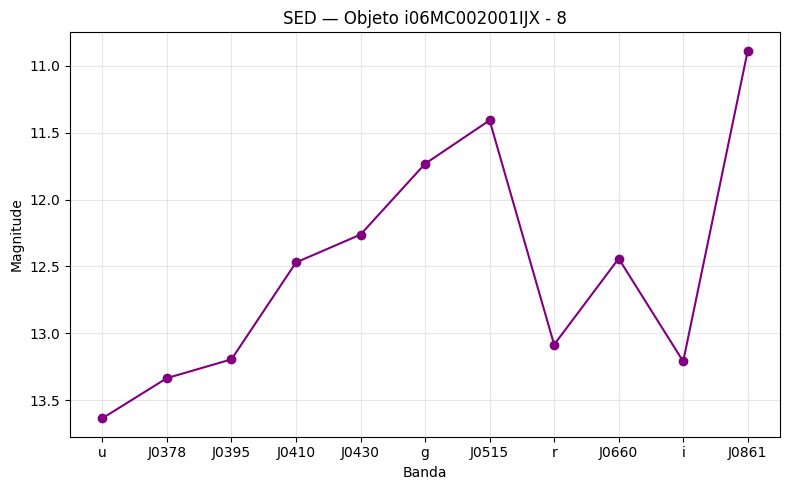

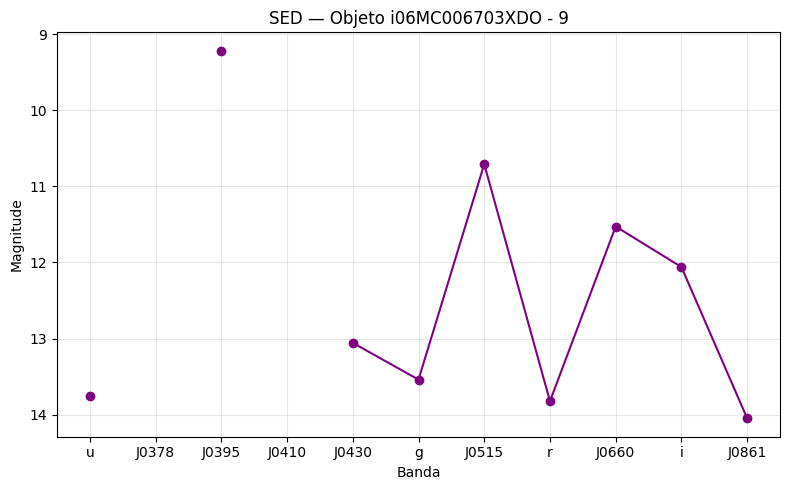

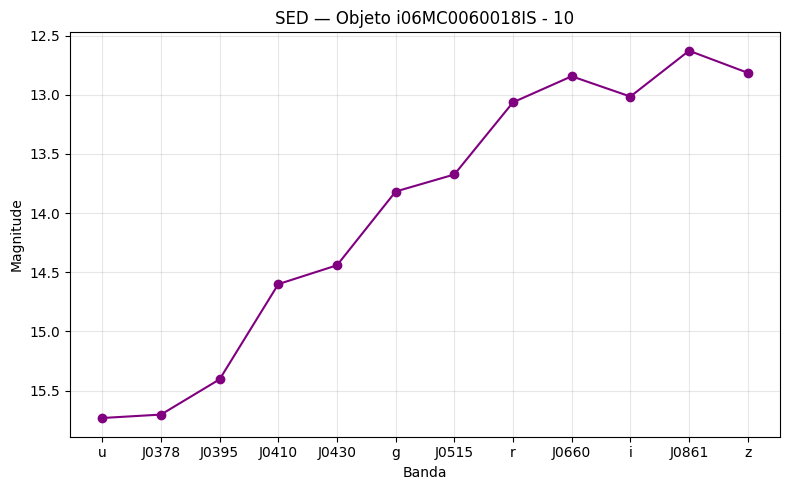

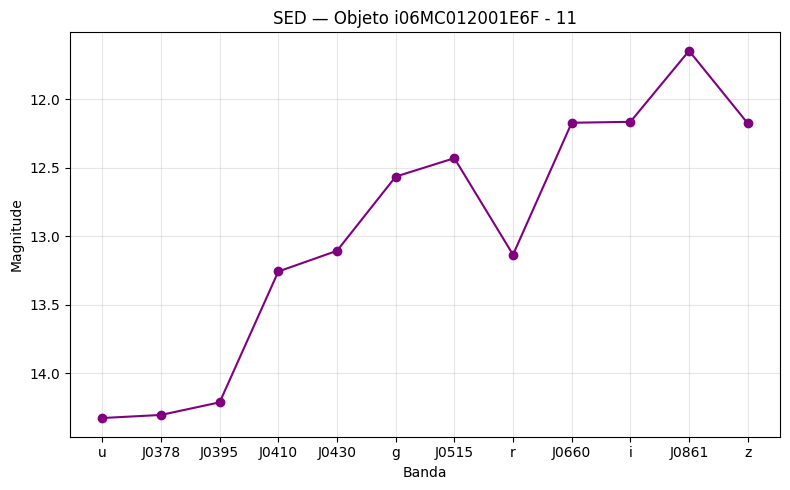

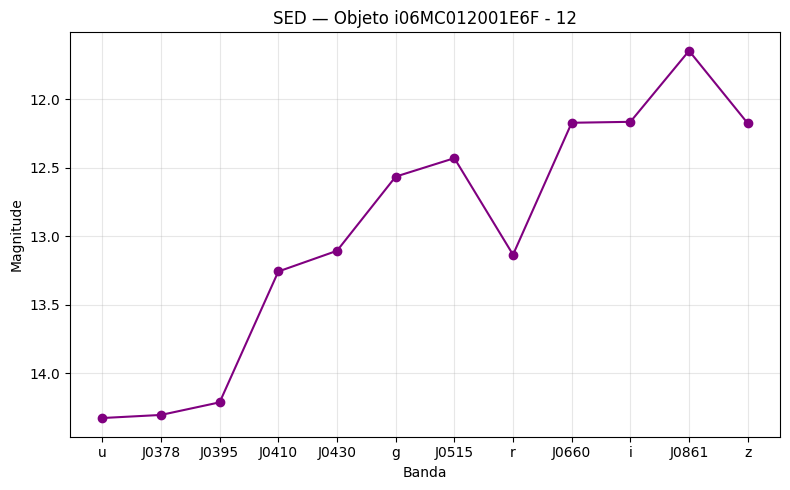

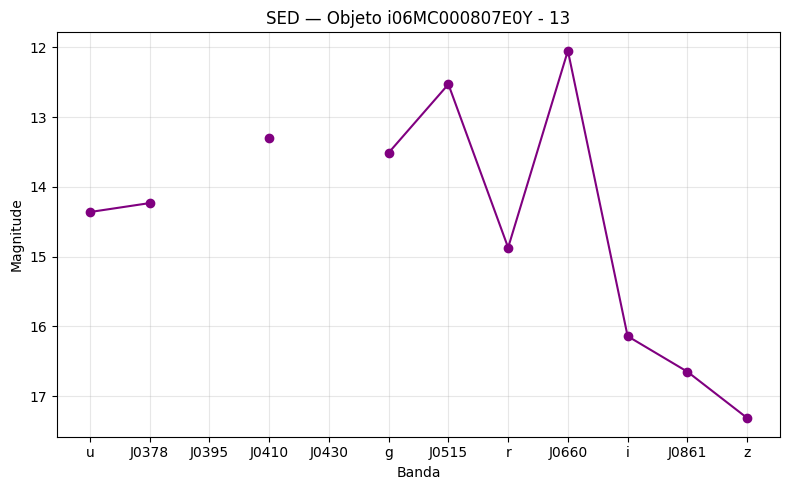

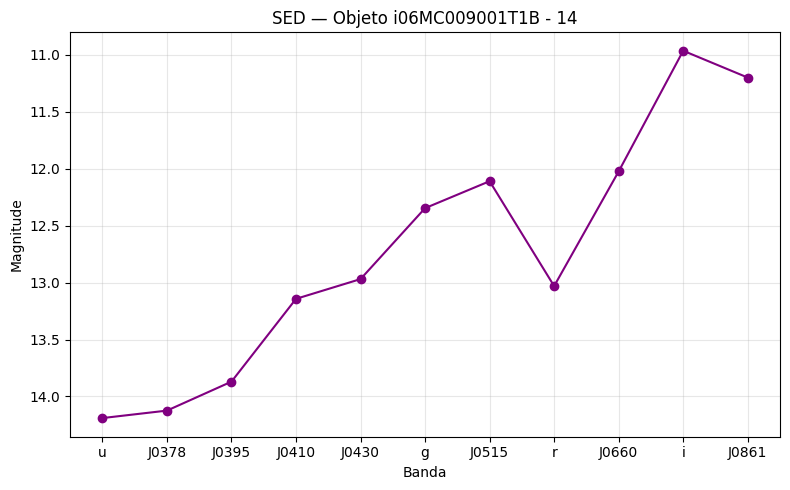

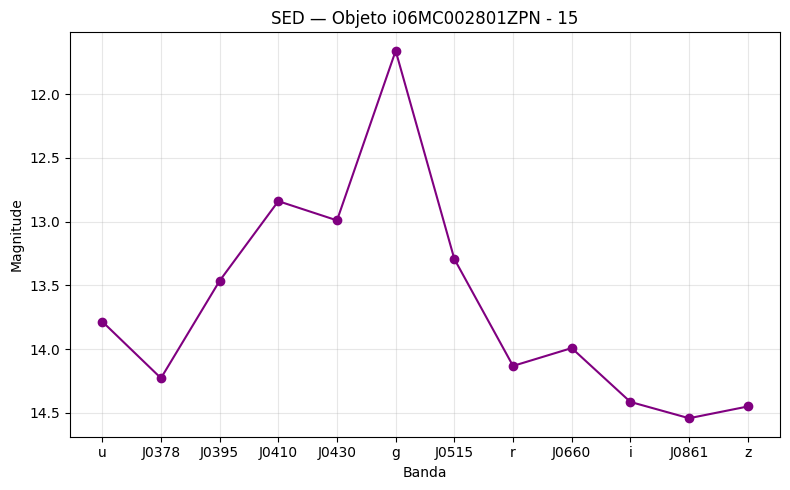

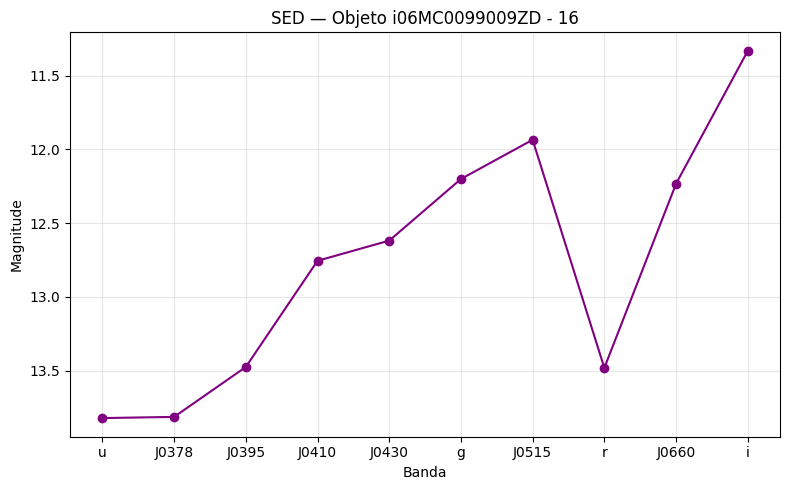

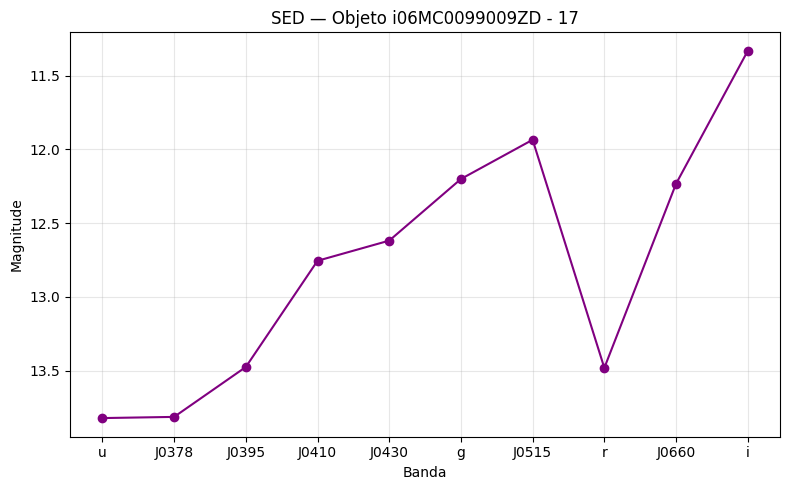

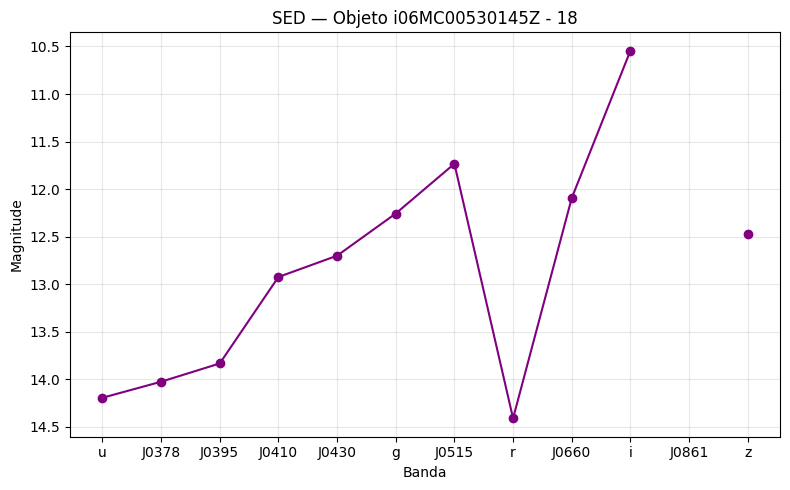

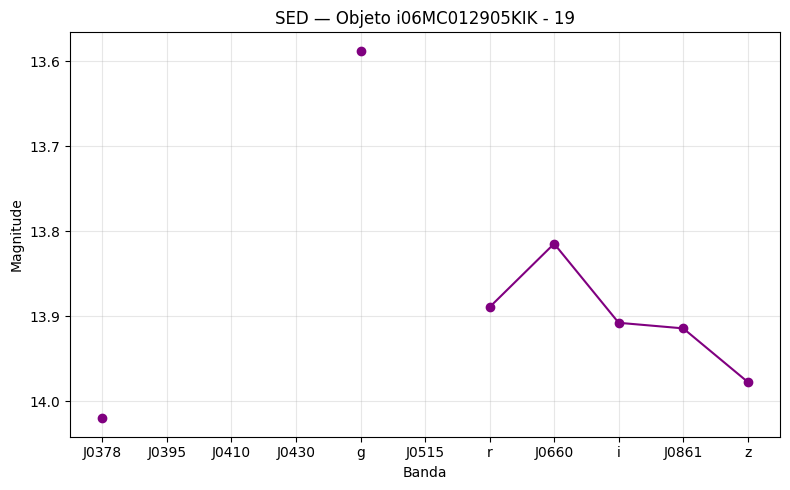

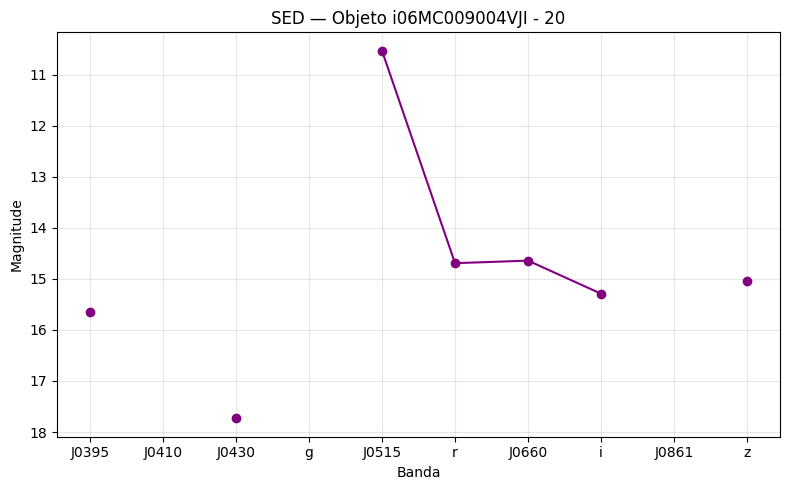

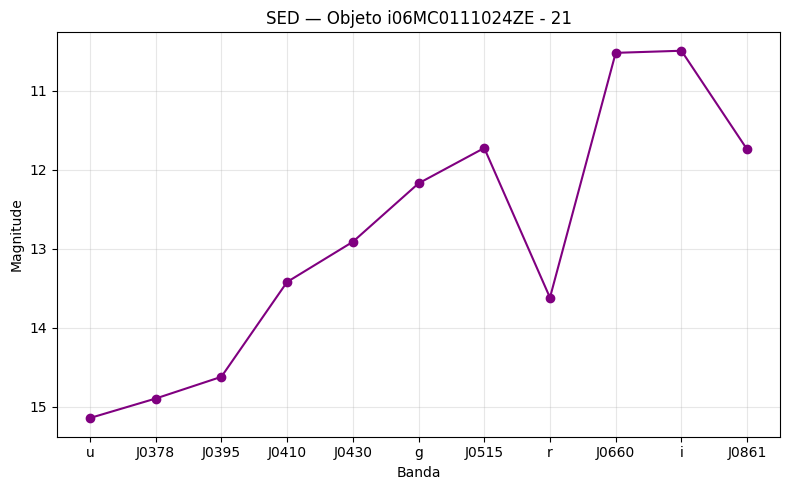

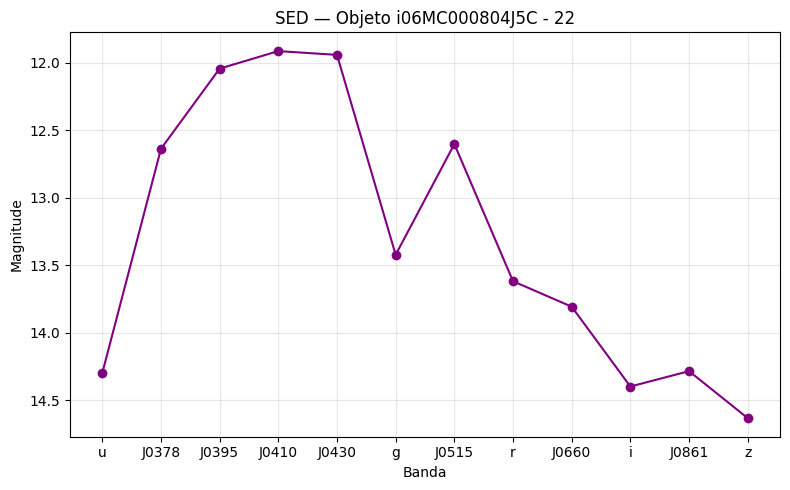

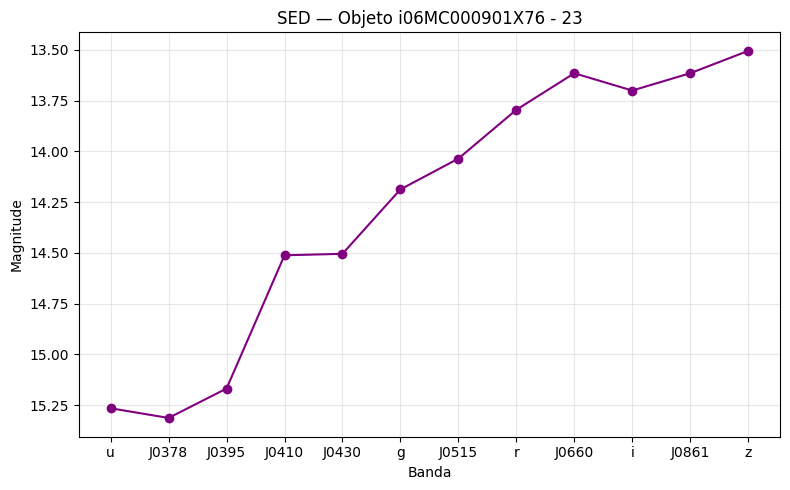

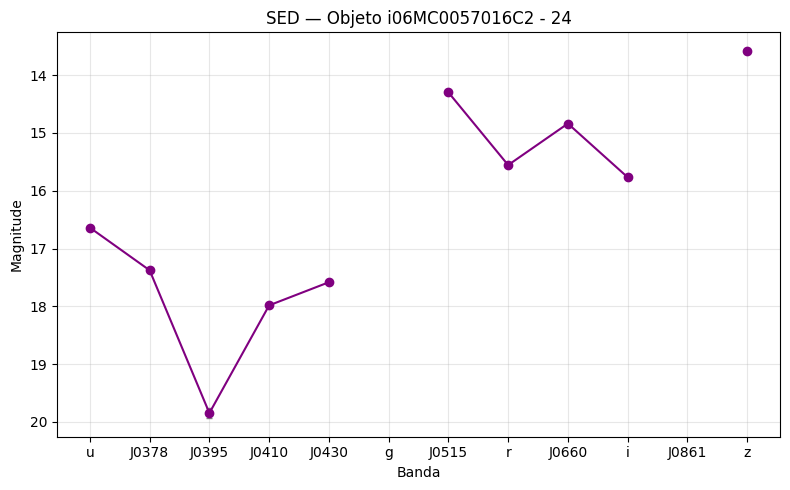

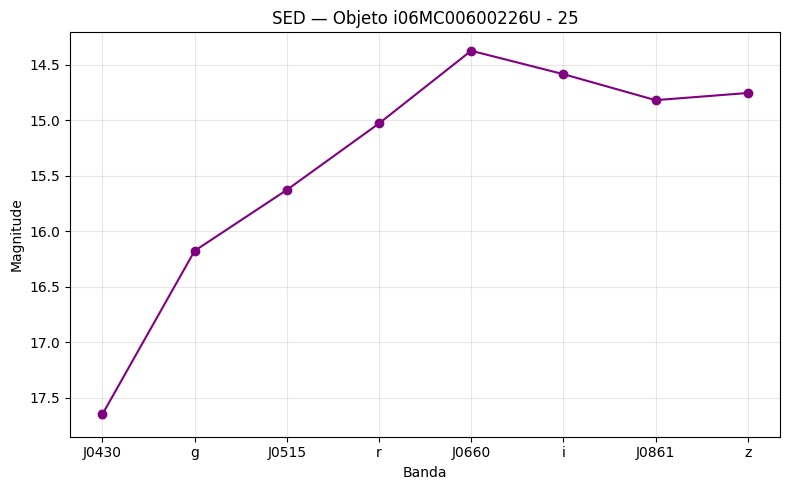

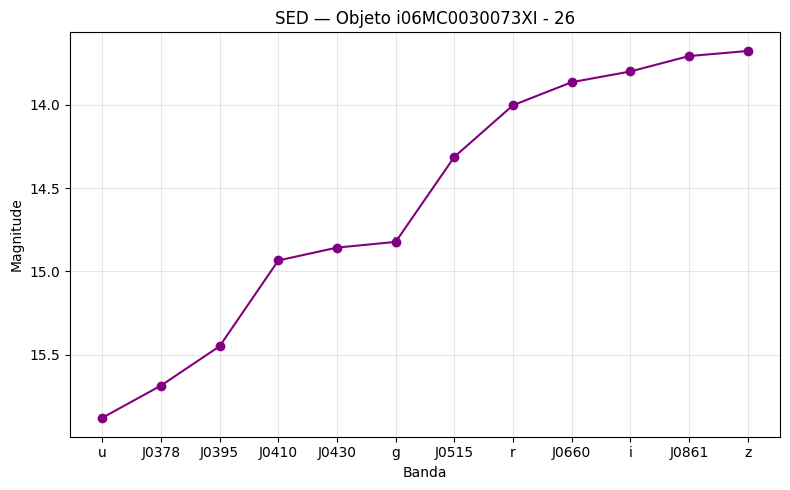

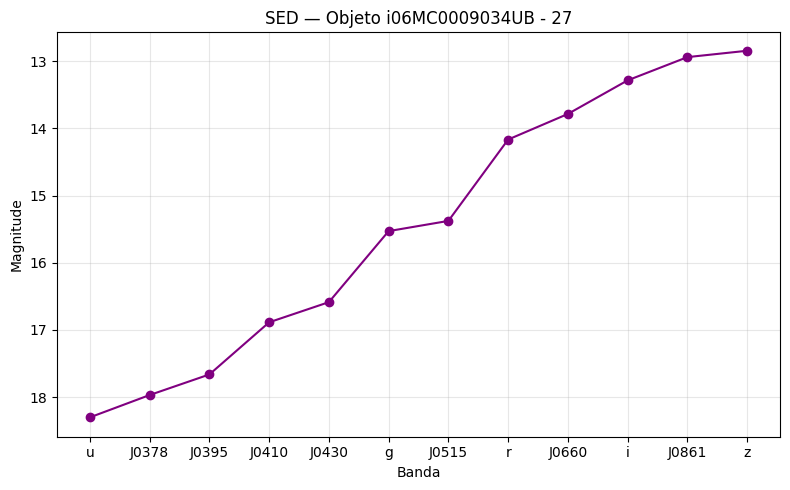

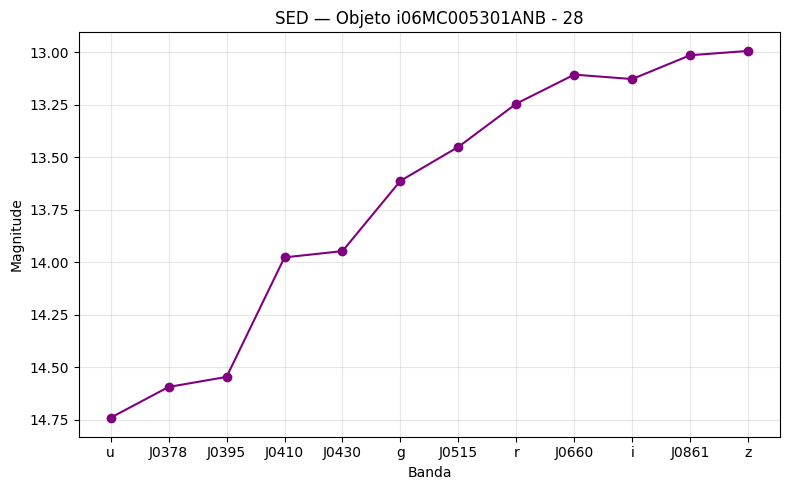

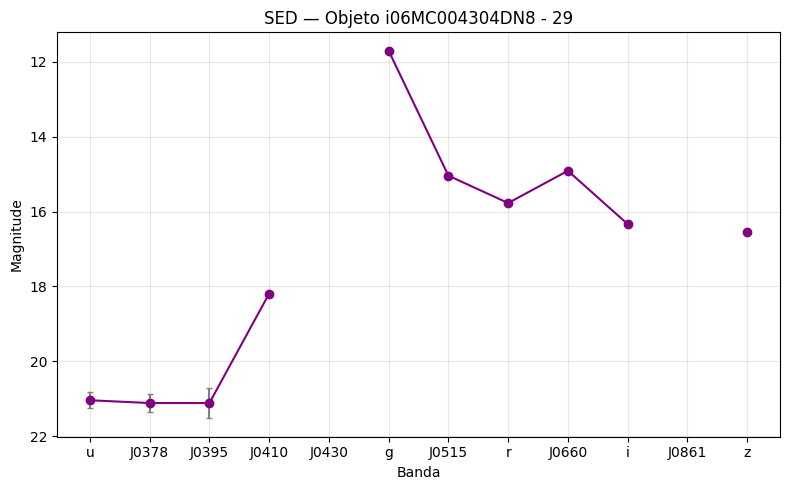

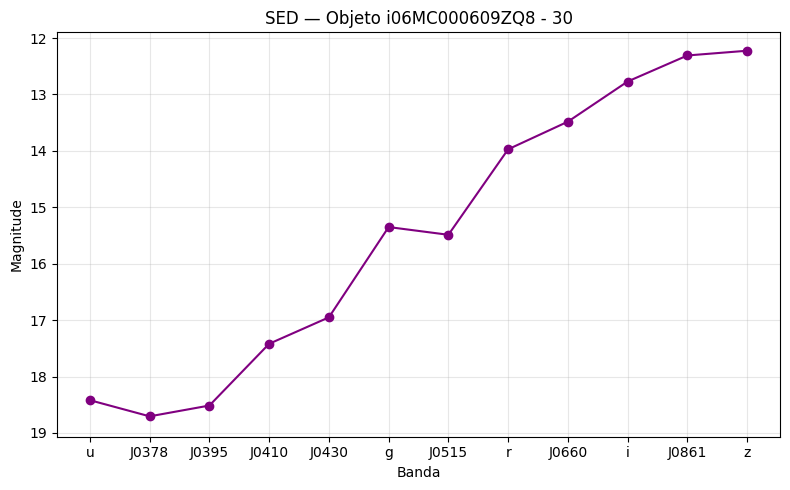

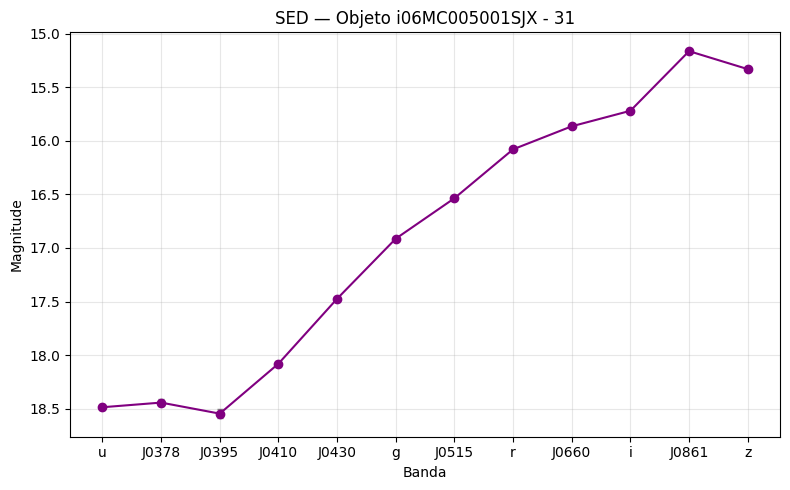

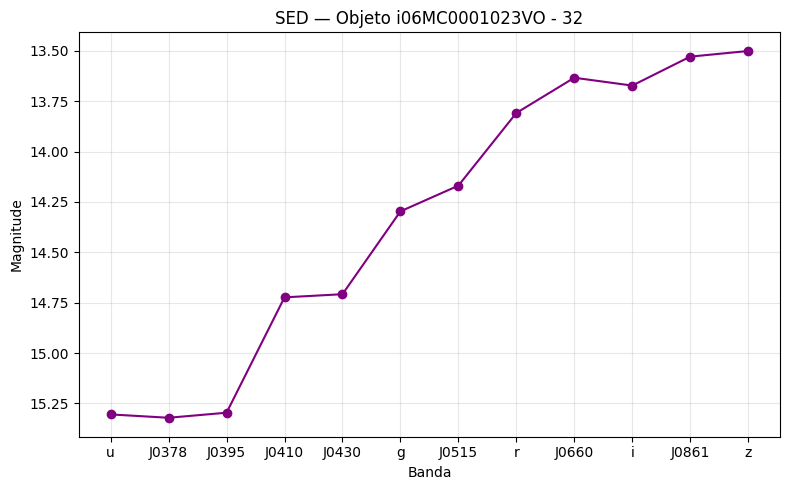

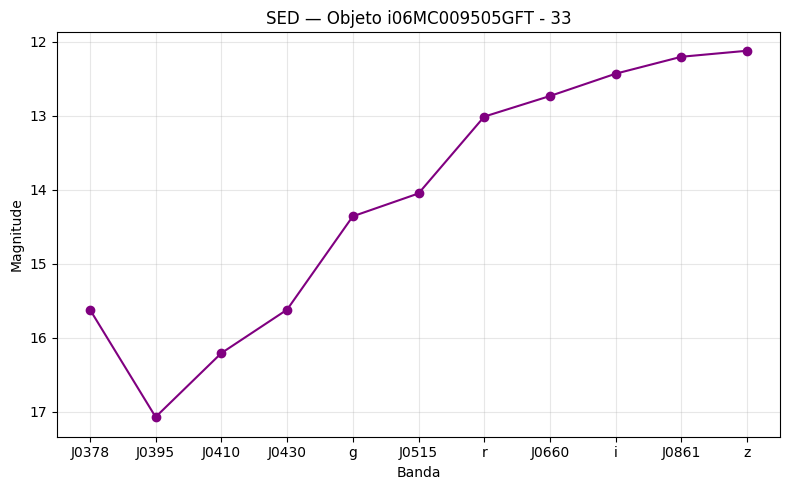

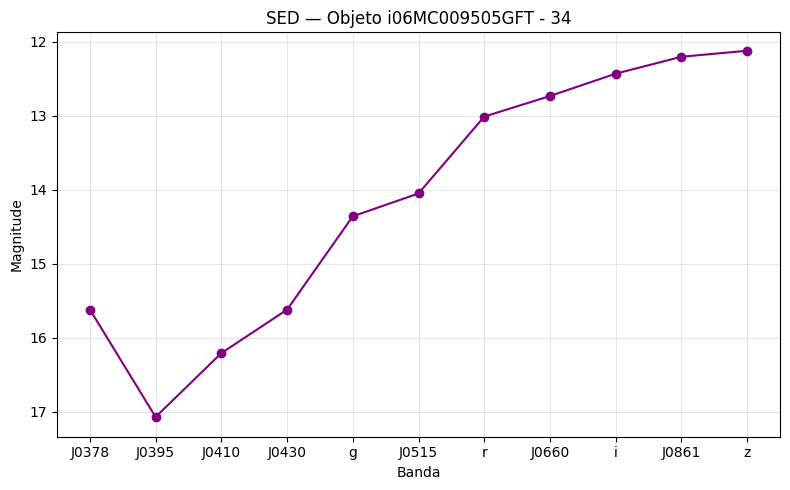

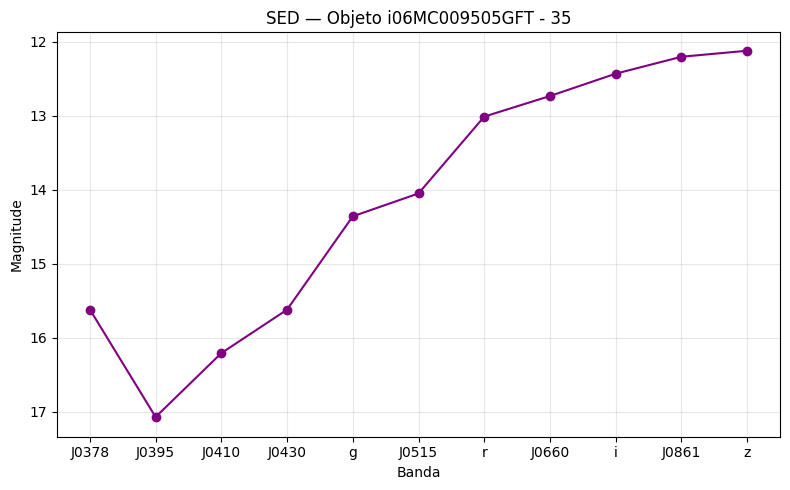

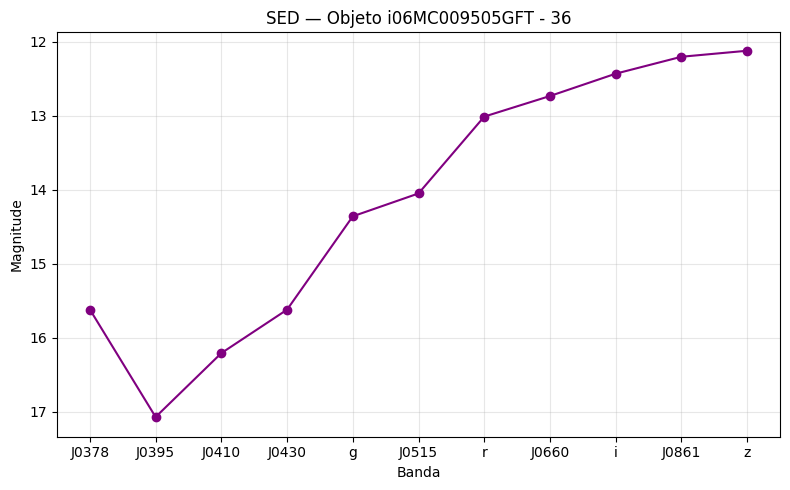

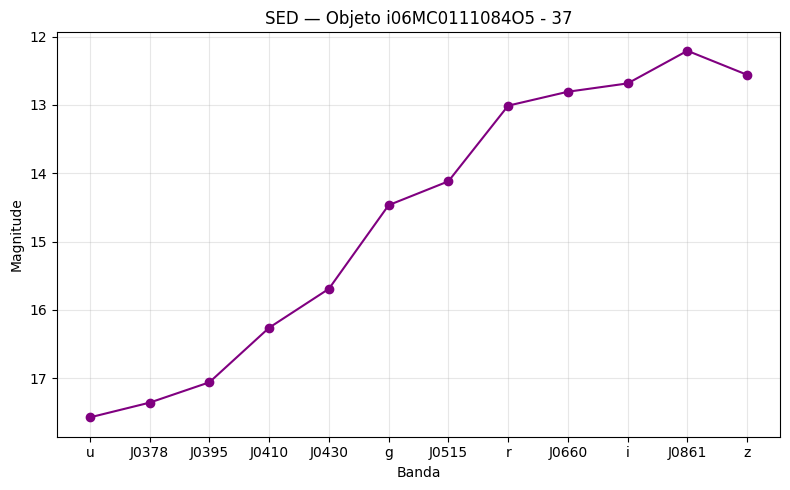

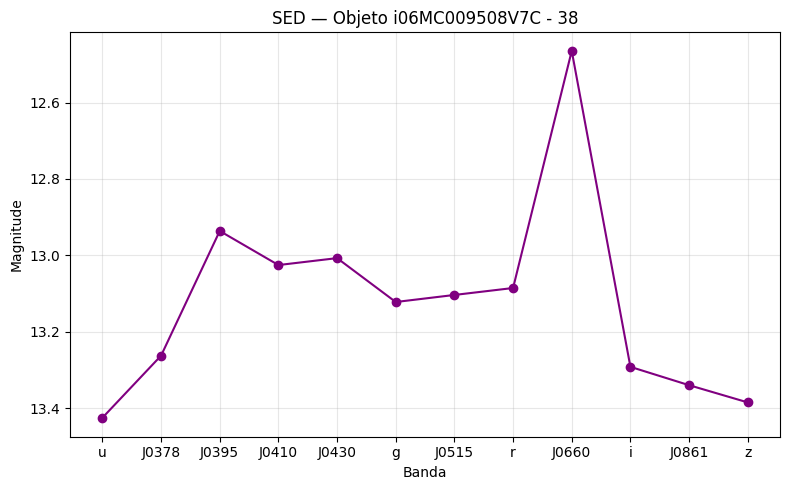

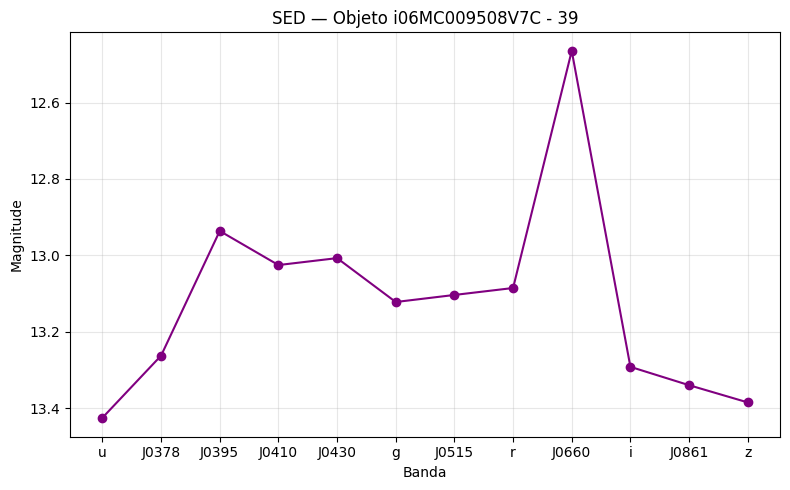

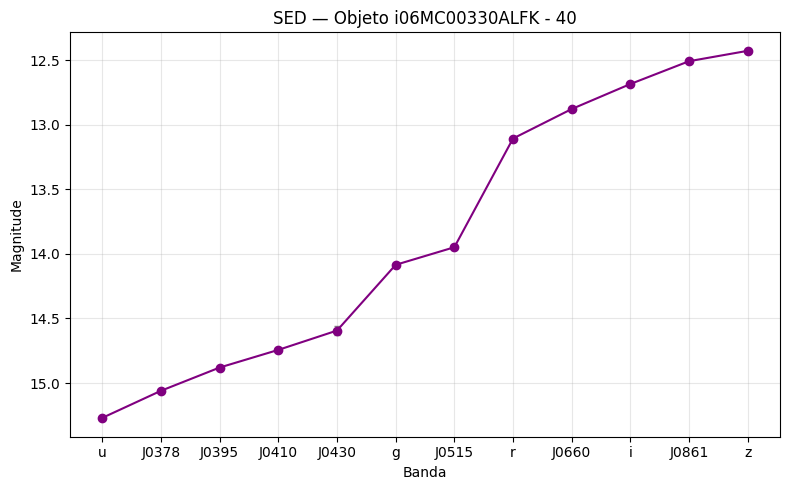

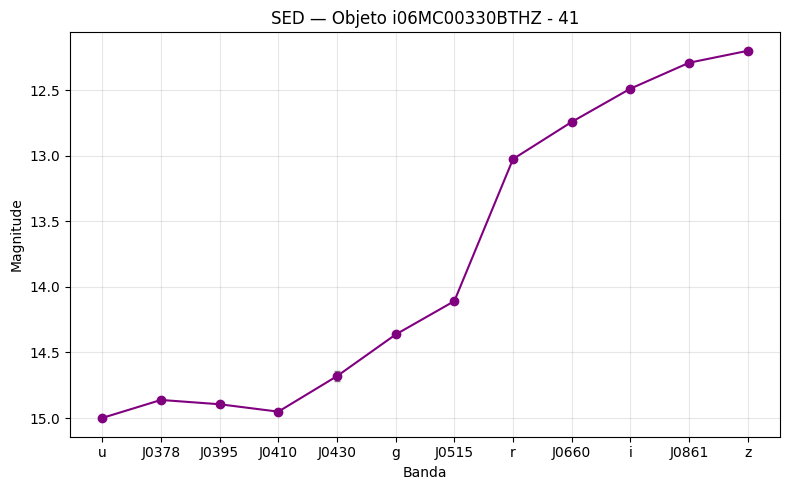

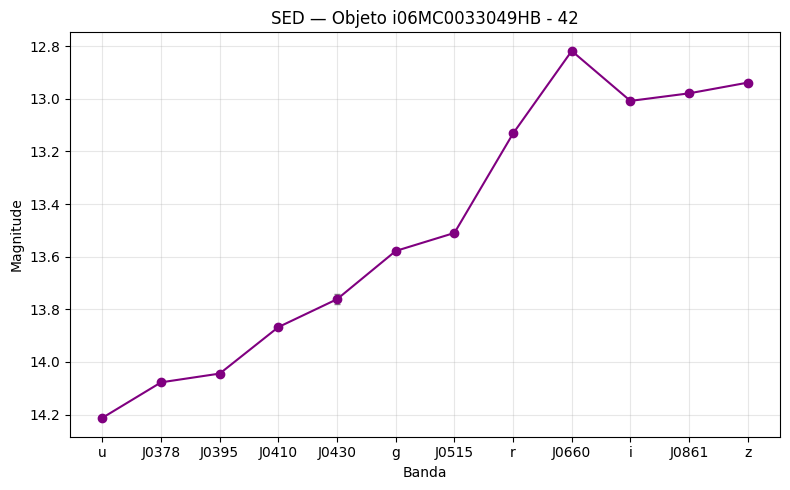

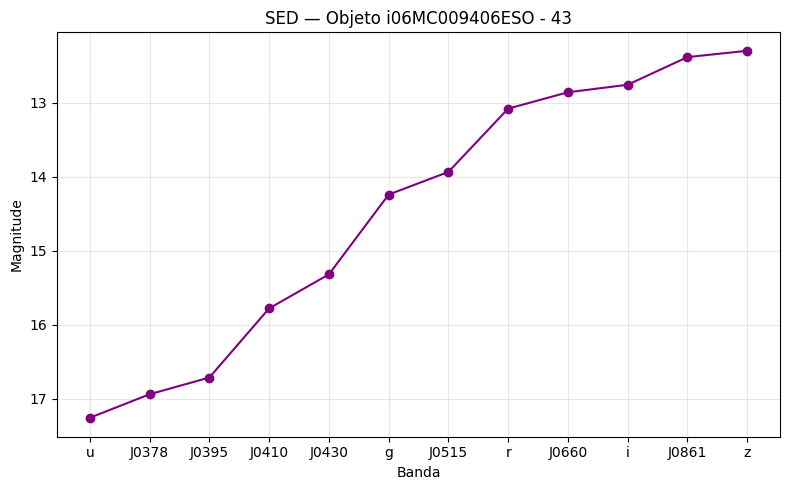

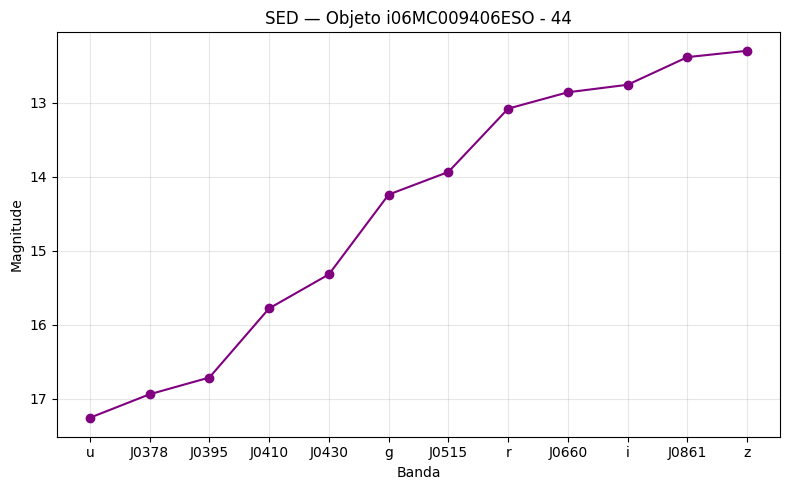

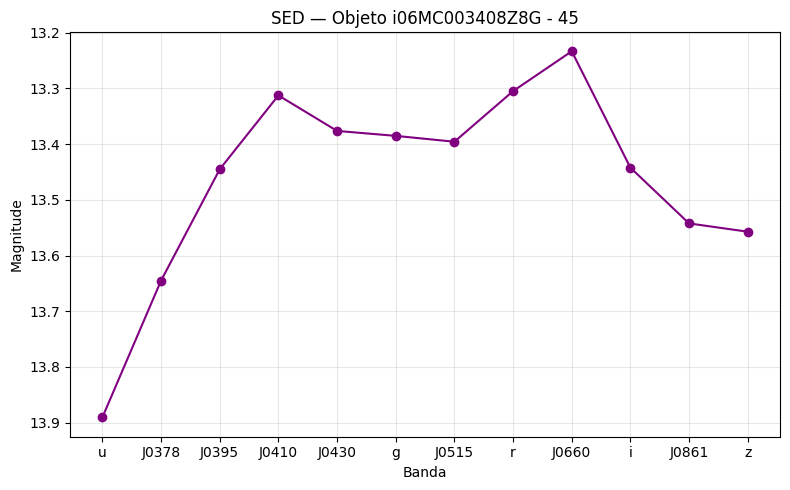

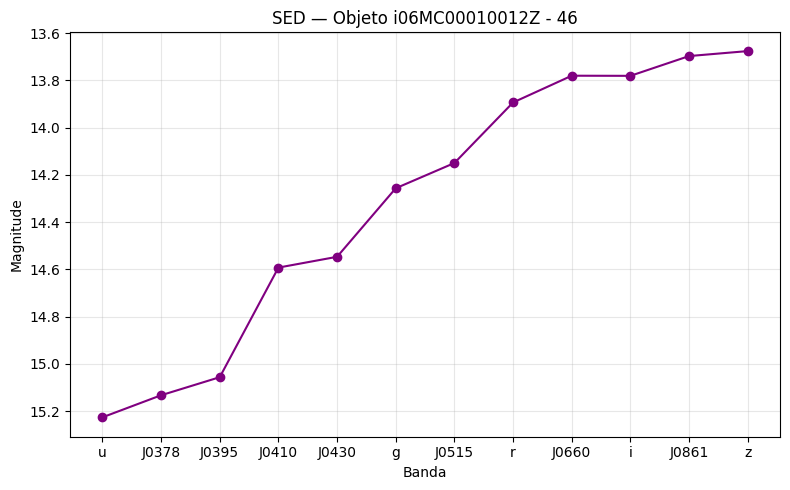

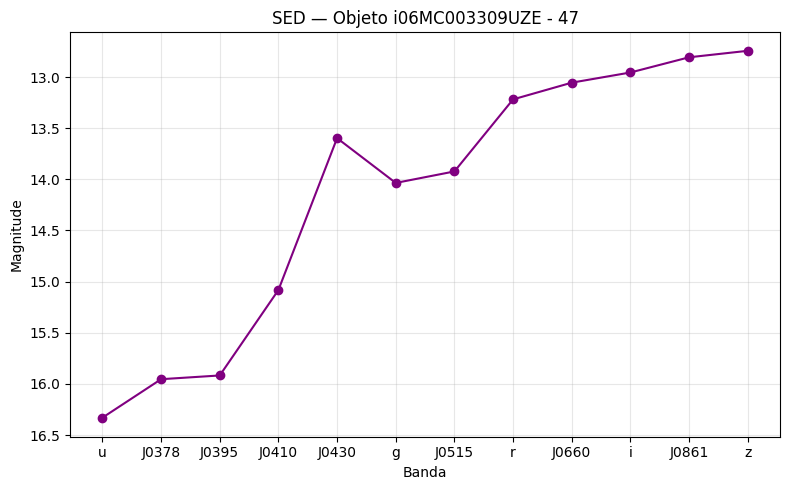

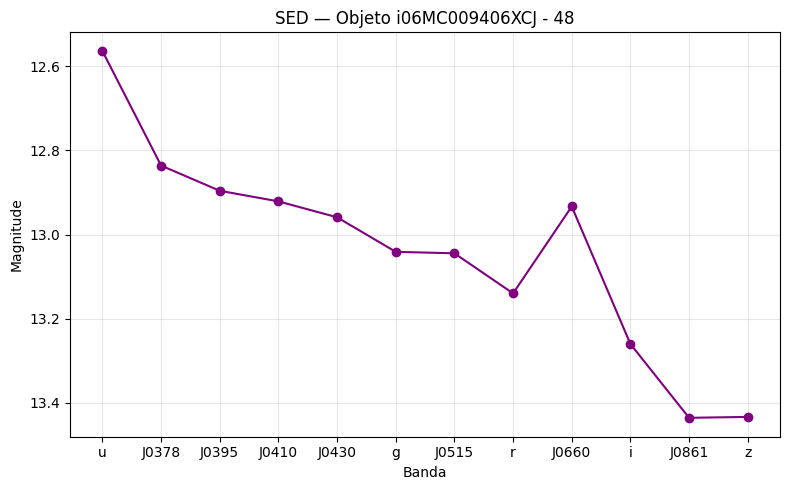

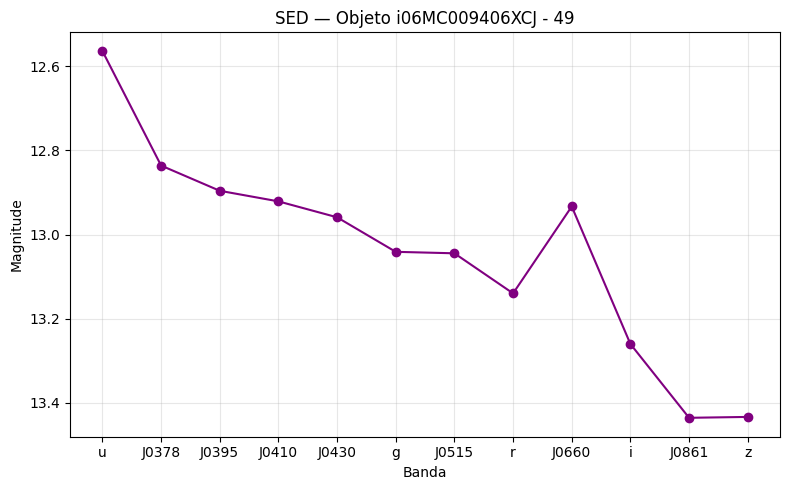

In [39]:
import numpy as np
import matplotlib.pyplot as plt

emitters = marks[marks['h_alpha_emitters_5sigma']]
bands = ['u', 'J0378', 'J0395', 'J0410', 'J0430', 'g', 'J0515', 'r', 'J0660', 'i', 'J0861', 'z']
wavelengths = np.array([3536, 3770, 3940, 4094, 4292, 4751, 5133, 6258, 6614, 7690, 8611, 8831])

mag_cols = [f"mag_psf_{b.lower()}" for b in bands]
err_cols = [f"err_mag_psf_{b.lower()}" for b in bands]
has_errors = all(col in emitters.columns for col in err_cols)

i = 0
for idx, row in emitters.iterrows():
    mags = row[mag_cols].to_numpy()

    plt.figure(figsize=(8, 5))
    if has_errors:
        errs = row[err_cols].to_numpy()
        plt.errorbar(bands, mags, yerr=errs, fmt='o-', color='purple', ecolor='gray', capsize=2)
    else:
        plt.plot(bands, mags, 'o-', color='purple')

    plt.gca().invert_yaxis()
    plt.xlabel('Banda')
    plt.ylabel('Magnitude')
    plt.title(f'SED — Objeto {row["id"]} - {i}')  # <<< usar a linha atual
    # plt.title(f'SED — Objeto {row['id']} - {row['main_type']}')  # se quiser incluir o tipo

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    i += 1
    if i >= 50:
        break